# analyse metrics per design methods

In [ ]:
import pandas as pd

df_all = pd.read_csv("data/original_data_a_bindcraft_a_boltzgen_prepared_column_names_updated.csv")

# 1. Count missing values
missing_count = df_all["source"].isna().sum()
print(f"Missing values in 'source': {missing_count}")

# 2. Show unique values
unique_values = df_all["source"].unique()
print("\nUnique values in 'source':")
print(unique_values)

# 3. Distribution across source (counts)
print("\nDistribution (counts):")
print(df_all["source"].value_counts(dropna=False))

# 4. Distribution across source (percentages)
print("\nDistribution (percent):")
print(df_all["source"].value_counts(normalize=True, dropna=False) * 100)

Missing values in 'source': 0

Unique values in 'source':
['pMHC screening NY1' 'pMHC screening NY2' 'pMHC screening SILSY1'
 'Cao et al VirB8' 'Cao et al FGFR2' 'IL7Ra Watson et al'
 'InsulinR Watson et al' 'Cao et al EGFR' 'Cao et al SARS_CoV2_RBD'
 'Pdl1 Watson et al' 'Adaptyv binder comp round 2' 'TrkA Watson et al'
 'Adaptyv binder comp round 1' 'Cao et al TrkA' 'Cao et al IL7Ra'
 'Bennet paper IL10Ra prospective' 'Bennet paper LTK prospective'
 'Mdm2 Watson et al' 'Cao et al Insulin receptor' 'Vazquez-Torres et al'
 'Bennet paper IL2Ra prospective' 'boltzgen_paper' 'bindcraft_paper']

Distribution (counts):
source
Cao et al FGFR2                    2123
boltzgen_paper                      392
bindcraft_paper                     212
Adaptyv binder comp round 2         175
Cao et al EGFR                      132
Adaptyv binder comp round 1         127
Cao et al VirB8                      99
Cao et al SARS_CoV2_RBD              99
pMHC screening SILSY1                96
Mdm2 Watson 

/tmp/ipykernel_3115597/1692620675.py:3: DtypeWarning: Columns (3,6,305,306,307,308,309,310,315,317,319,321,322,323,324,325,326,327,328,329,333,338) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/notebooks_boltz_and_bindcraft/original_data_a_bindcraft_a_boltzgen_prepared_column_names_updated.csv")


In [2]:
from matplotlib import font_manager
import matplotlib.pyplot as plt

font_manager.fontManager.addfont("../data/arial/ARIAL.TTF")
font_manager.fontManager.addfont("../data/arial/ARIALBD.TTF")
plt.rcParams.update({
    'font.family': 'Arial',          # or 'sans-serif' if required by the journal
    'font.size': 12,                 # main font size
    'axes.labelsize': 13,            # axis labels
    'axes.titlesize': 13,            # title
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 14
})

In [3]:
import pandas as pd

df_all = pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/notebooks_boltz_and_bindcraft/original_data_a_bindcraft_a_boltzgen_prepared_column_names_updated.csv")

source_map = {
    "pMHC screening NY1": "Johansen et al. 2025",
    "pMHC screening NY2": "Johansen et al. 2025",
    "pMHC screening SILSY1": "Johansen et al. 2025",

    "Cao et al VirB8": "Cao et al. 2022",
    "Cao et al FGFR2": "Cao et al. 2022",
    "Cao et al EGFR": "Cao et al. 2022",
    "Cao et al SARS_CoV2_RBD": "Cao et al. 2022",
    "Cao et al TrkA": "Cao et al. 2022",
    "Cao et al IL7Ra": "Cao et al. 2022",
    "Cao et al Insulin receptor": "Cao et al. 2022",

    "IL7Ra Watson et al": "Watson et al. 2023",
    "InsulinR Watson et al": "Watson et al. 2023",
    "Pdl1 Watson et al": "Watson et al. 2023",
    "TrkA Watson et al": "Watson et al. 2023",
    "Mdm2 Watson et al": "Watson et al. 2023",

    "Adaptyv binder comp round 1": "Adaptyv Bio Competition EGFR",
    "Adaptyv binder comp round 2": "Adaptyv Bio Competition EGFR",

    "Bennet paper IL10Ra prospective": "Bennet et al. 2023",
    "Bennet paper LTK prospective": "Bennet et al. 2023",
    "Bennet paper IL2Ra prospective": "Bennet et al. 2023",

    "Vazquez-Torres et al": "Vazquez-Torres et al. 2025",

    "boltzgen_paper": "Stark et al. 2025 (Boltzgen)",
    "bindcraft_paper": "Pacesa et al. 2025 (BindCraft)"
}

# Create clean_source column
df_all["clean_source"] = df_all["source"].map(source_map)

# Check if any sources were not mapped
unmapped = df_all[df_all["clean_source"].isna()]["source"].unique()
print("Unmapped sources:", unmapped)

# Distribution
print(df_all["clean_source"].value_counts())


Unmapped sources: []
clean_source
Cao et al. 2022                   2585
Watson et al. 2023                 475
Stark et al. 2025 (Boltzgen)       392
Adaptyv Bio Competition EGFR       302
Johansen et al. 2025               228
Pacesa et al. 2025 (BindCraft)     212
Bennet et al. 2023                 121
Vazquez-Torres et al. 2025          49
Name: count, dtype: int64


/tmp/ipykernel_3115597/835148851.py:3: DtypeWarning: Columns (3,6,305,306,307,308,309,310,315,317,319,321,322,323,324,325,326,327,328,329,333,338) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/notebooks_boltz_and_bindcraft/original_data_a_bindcraft_a_boltzgen_prepared_column_names_updated.csv")


# add design method

In [4]:
# Mapping from clean_source -> design method
design_method_map = {
    "Cao et al. 2022": "Physics Based (Rosetta)",
    "Watson et al. 2023": "RF-diffusion",
    "Stark et al. 2025 (Boltzgen)": "Boltzgen",
    "Adaptyv Bio Competition EGFR": "Mixed",
    "Johansen et al. 2025": "RF-diffusion",
    "Pacesa et al. 2025 (BindCraft)": "BindCraft",
    "Bennet et al. 2023": "RF-diffusion",
    "Vazquez-Torres et al. 2025": "RF-diffusion"
}

# Create new column
df_all["design_method"] = df_all["clean_source"].map(design_method_map)

# Check if any clean_source values were not mapped
unmapped_methods = df_all[df_all["design_method"].isna()]["clean_source"].unique()
print("Unmapped design methods:", unmapped_methods)

# Distribution
print("\nDesign method distribution:")
print(df_all["design_method"].value_counts())

Unmapped design methods: []

Design method distribution:
design_method
Physics Based (Rosetta)    2585
RF-diffusion                873
Boltzgen                    392
Mixed                       302
BindCraft                   212
Name: count, dtype: int64


In [5]:
df_all["binder"].describe()
print(df_all["binder"].unique())

# 1. Count missing values
missing_count = df_all["binder"].isna().sum()
print(f"Missing values in 'binder': {missing_count}")

df_old=pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/data/prepared_training_dataset_publish.csv")
print(df_old["binder"].unique())

df_bc=pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/notebooks_boltz_and_bindcraft/bindcraft_predicted_and_experimental_data.csv")
print(df_bc["binder"].unique(),"bind_craft")

df_bg=pd.read_csv("//zhome/projects/project.maxove.anryg/classifying_binders/notebooks_boltz_and_bindcraft/boltzgen_predicted_and_experimental_data.csv")
print(df_bg["binder"].unique(),"boltzgen")



[0 1 '0' '1' 'True' 'False' nan]
Missing values in 'binder': 98
[0 1]
[False True nan] bind_craft
[True False nan] boltzgen


In [6]:

def normalize_labels(y):
    """
    Convert mixed label formats to clean binary labels (0/1).
    Handles:
        0,1
        '0','1'
        True,False
        'True','False'
        NaN
    Returns:
        numpy array of 0/1
    """

    y = pd.Series(y)

    mapping = {
        True: 1,
        False: 0,
        'True': 1,
        'False': 0,
        'true': 1,
        'false': 0,
        '1': 1,
        '0': 0,
        1: 1,
        0: 0
    }

    y_clean = y.map(mapping)

    return y_clean.astype(float)

df = df_all.copy()

df["binder"] = normalize_labels(df["binder"])

df = df.dropna(subset=["binder"])
df["binder"] = df["binder"].astype(int)
df["binder"].unique()
df_ready=df.copy()

# DROP NANOBODIES FROM BOLTZGEN

In [7]:
# Count how many rows will be dropped
mask_drop = (df_ready["design_method"] == "Boltzgen") & df_ready["binder_id"].str.contains("nano", case=False, na=False)
num_dropped = mask_drop.sum()
print(f"Number of Boltzgen binders with 'nano' in binder_id to drop: {num_dropped} out of {len(df_ready[df_all['design_method'] == 'Boltzgen'])}")

# Drop these rows
df_filtered = df_ready[~mask_drop].copy()


# Optional: check the new shape
print(f"Original shape: {df_ready.shape}, New shape: {df_filtered.shape}")
df_ready=df_filtered.copy()

Number of Boltzgen binders with 'nano' in binder_id to drop: 172 out of 361
Original shape: (4266, 341), New shape: (4094, 341)


/tmp/ipykernel_3115597/986487838.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f"Number of Boltzgen binders with 'nano' in binder_id to drop: {num_dropped} out of {len(df_ready[df_all['design_method'] == 'Boltzgen'])}")


# akk data together per design method

In [57]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score

# --- Params ---
MODEL_TAGS = ['af2', 'colab', 'boltz', 'af3']

df = df_ready.copy()
df['binder'] = df['binder'].astype(int)

feature_cols = [c for c in df.columns if c not in ['binder','design_method']]

label_map = {
    'af2':    'AF2 initial guess',
    'colab':  'ColabFold',
    'boltz':  'Boltz-1',
    'af3':    'AF3',
}

# --- Utility functions ---
def best_ap_and_direction(vals, y):
    vals = pd.to_numeric(vals, errors='coerce').fillna(0)
    if vals.isna().all():
        return np.nan, None
    try:
        ap_high = average_precision_score(y, vals)
        ap_low  = average_precision_score(y, -vals)
    except ValueError:
        return np.nan, None
    if (not np.isnan(ap_high) and ap_high >= ap_low) or np.isnan(ap_low):
        return ap_high, False
    else:
        return ap_low, True


def valid_feature_for_model(feat, model_tag, model_tags):
    tags_in_feat = [t for t in model_tags if t in feat]

    if feat.startswith("input"):
        return (len(tags_in_feat) == 0) or (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)
    else:
        return (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)


def format_feature_name(feat, model_tags):

    if "*" in feat:
        f1, f2 = feat.split("*")

        for mt in model_tags:
            f1 = f1.replace(mt + "_", "")
            f2 = f2.replace(mt + "_", "")

        f1 = f1.replace("rosetta_", "").replace("rosetta", "")
        f2 = f2.replace("rosetta_", "").replace("rosetta", "")

        f1 = f1.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        f2 = f2.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')

        f1 = f1.replace("sap_delta", r'$\Delta$SAP')
        f2 = f2.replace("sap_delta", r'$\Delta$SAP')

        f1 = f1.replace("dockQ", 'DockQ')

        return f"{f1} × {f2}"

    else:
        for mt in model_tags:
            feat = feat.replace(mt + "_", "")

        feat = feat.replace("sap_delta", r'$\Delta$SAP')

        return feat.replace("rosetta_", "").replace("rosetta", "")


# --- Compute AP scores ---
results_features = []
results_interactions = []

for method in df['design_method'].unique():

    df_m = df[df['design_method'] == method]

    for tag in MODEL_TAGS:

        feats = [
            c for c in feature_cols
            if valid_feature_for_model(c, tag, MODEL_TAGS)
        ]

        feats = sorted(set(feats))

        # --- Single features ---
        for feat in feats:
            ap, is_lower = best_ap_and_direction(df_m[feat], df_m['binder'])

            results_features.append({
                'design_method': method,
                'model': tag,
                'feature': feat,
                'ap': ap,
                'lower_is_better': is_lower
            })

        # --- Interaction features ---
        for i, f1 in enumerate(feats):
            for f2 in feats[i+1:]:

                v1 = pd.to_numeric(df_m[f1], errors='coerce').fillna(0)
                v2 = pd.to_numeric(df_m[f2], errors='coerce').fillna(0)

                inter = v1 * v2

                ap, is_lower = best_ap_and_direction(inter, df_m['binder'])

                results_interactions.append({
                    'design_method': method,
                    'model': tag,
                    'feature': f"{f1}*{f2}",
                    'ap': ap,
                    'lower_is_better': is_lower
                })

df_feats = pd.DataFrame(results_features).dropna(subset=['ap'])
df_inters = pd.DataFrame(results_interactions).dropna(subset=['ap'])

# --- Select best metrics ---
top_single = (
    df_feats.sort_values('ap', ascending=False)
    .groupby(['design_method','model'])
    .head(1)
)

top_inter = (
    df_inters.sort_values('ap', ascending=False)
    .groupby(['design_method','model'])
    .head(1)
)

# --- Build plotting dataframe ---
rows = []

for _, row in top_single.iterrows():
    rows.append({
        'feature': f"{format_feature_name(row['feature'], MODEL_TAGS)} ({label_map[row['model']]})",
        'ap': row['ap'],
        'design_method': row['design_method'],
        'model_label': label_map[row['model']],
        'kind': 'Single'
    })

for _, row in top_inter.iterrows():
    rows.append({
        'feature': f"{format_feature_name(row['feature'], MODEL_TAGS)} ({label_map[row['model']]})",
        'ap': row['ap'],
        'design_method': row['design_method'],
        'model_label': label_map[row['model']],
        'kind': 'Interaction'
    })

# --- BASELINE COMPUTATION (robust) ---
baseline_rows = []

for method in df['design_method'].unique():

    df_m = df[df['design_method'] == method]

    if 'af3_ipSAE_min' not in df_m.columns:
        print(f"[WARNING] {method}: missing column 'af3_ipSAE_min'")
        continue

    ap, _ = best_ap_and_direction(df_m['af3_ipSAE_min'], df_m['binder'])

    if np.isnan(ap):
        print(f"[WARNING] {method}: baseline AP is NaN")
        continue

    baseline_rows.append({
        'feature': 'ipSAE_min (AF3)',
        'ap': ap,
        'design_method': method,
        'model_label': 'AF3',
        'kind': 'Baseline'
    })

# --- Combine ---
df_plot = pd.concat([pd.DataFrame(rows), pd.DataFrame(baseline_rows)], ignore_index=True)

# --- Ordering ---
design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    'Mixed'
][::-1]

model_order = [
    'AF3',
    'Boltz-1',
    'ColabFold',
    'AF2 initial guess'
]

kind_order = ['Baseline','Single','Interaction']

df_plot['design_method'] = pd.Categorical(df_plot['design_method'], categories=design_order, ordered=True)
df_plot['model_label'] = pd.Categorical(df_plot['model_label'], categories=model_order, ordered=True)
df_plot['kind'] = pd.Categorical(df_plot['kind'], categories=kind_order, ordered=True)

df_plot = df_plot.sort_values(['design_method','kind','model_label']).reset_index(drop=True)


# --- Dataset composition summary (unchanged) ---
summary = (
    df.groupby(['design_method','binder'])
    .size()
    .unstack(fill_value=0)
)

summary = summary.rename(columns={0:'Negative',1:'Positive'})

In [58]:
df_plot.to_csv("df_plotting_AP_per_medhod.csv")

# plotting

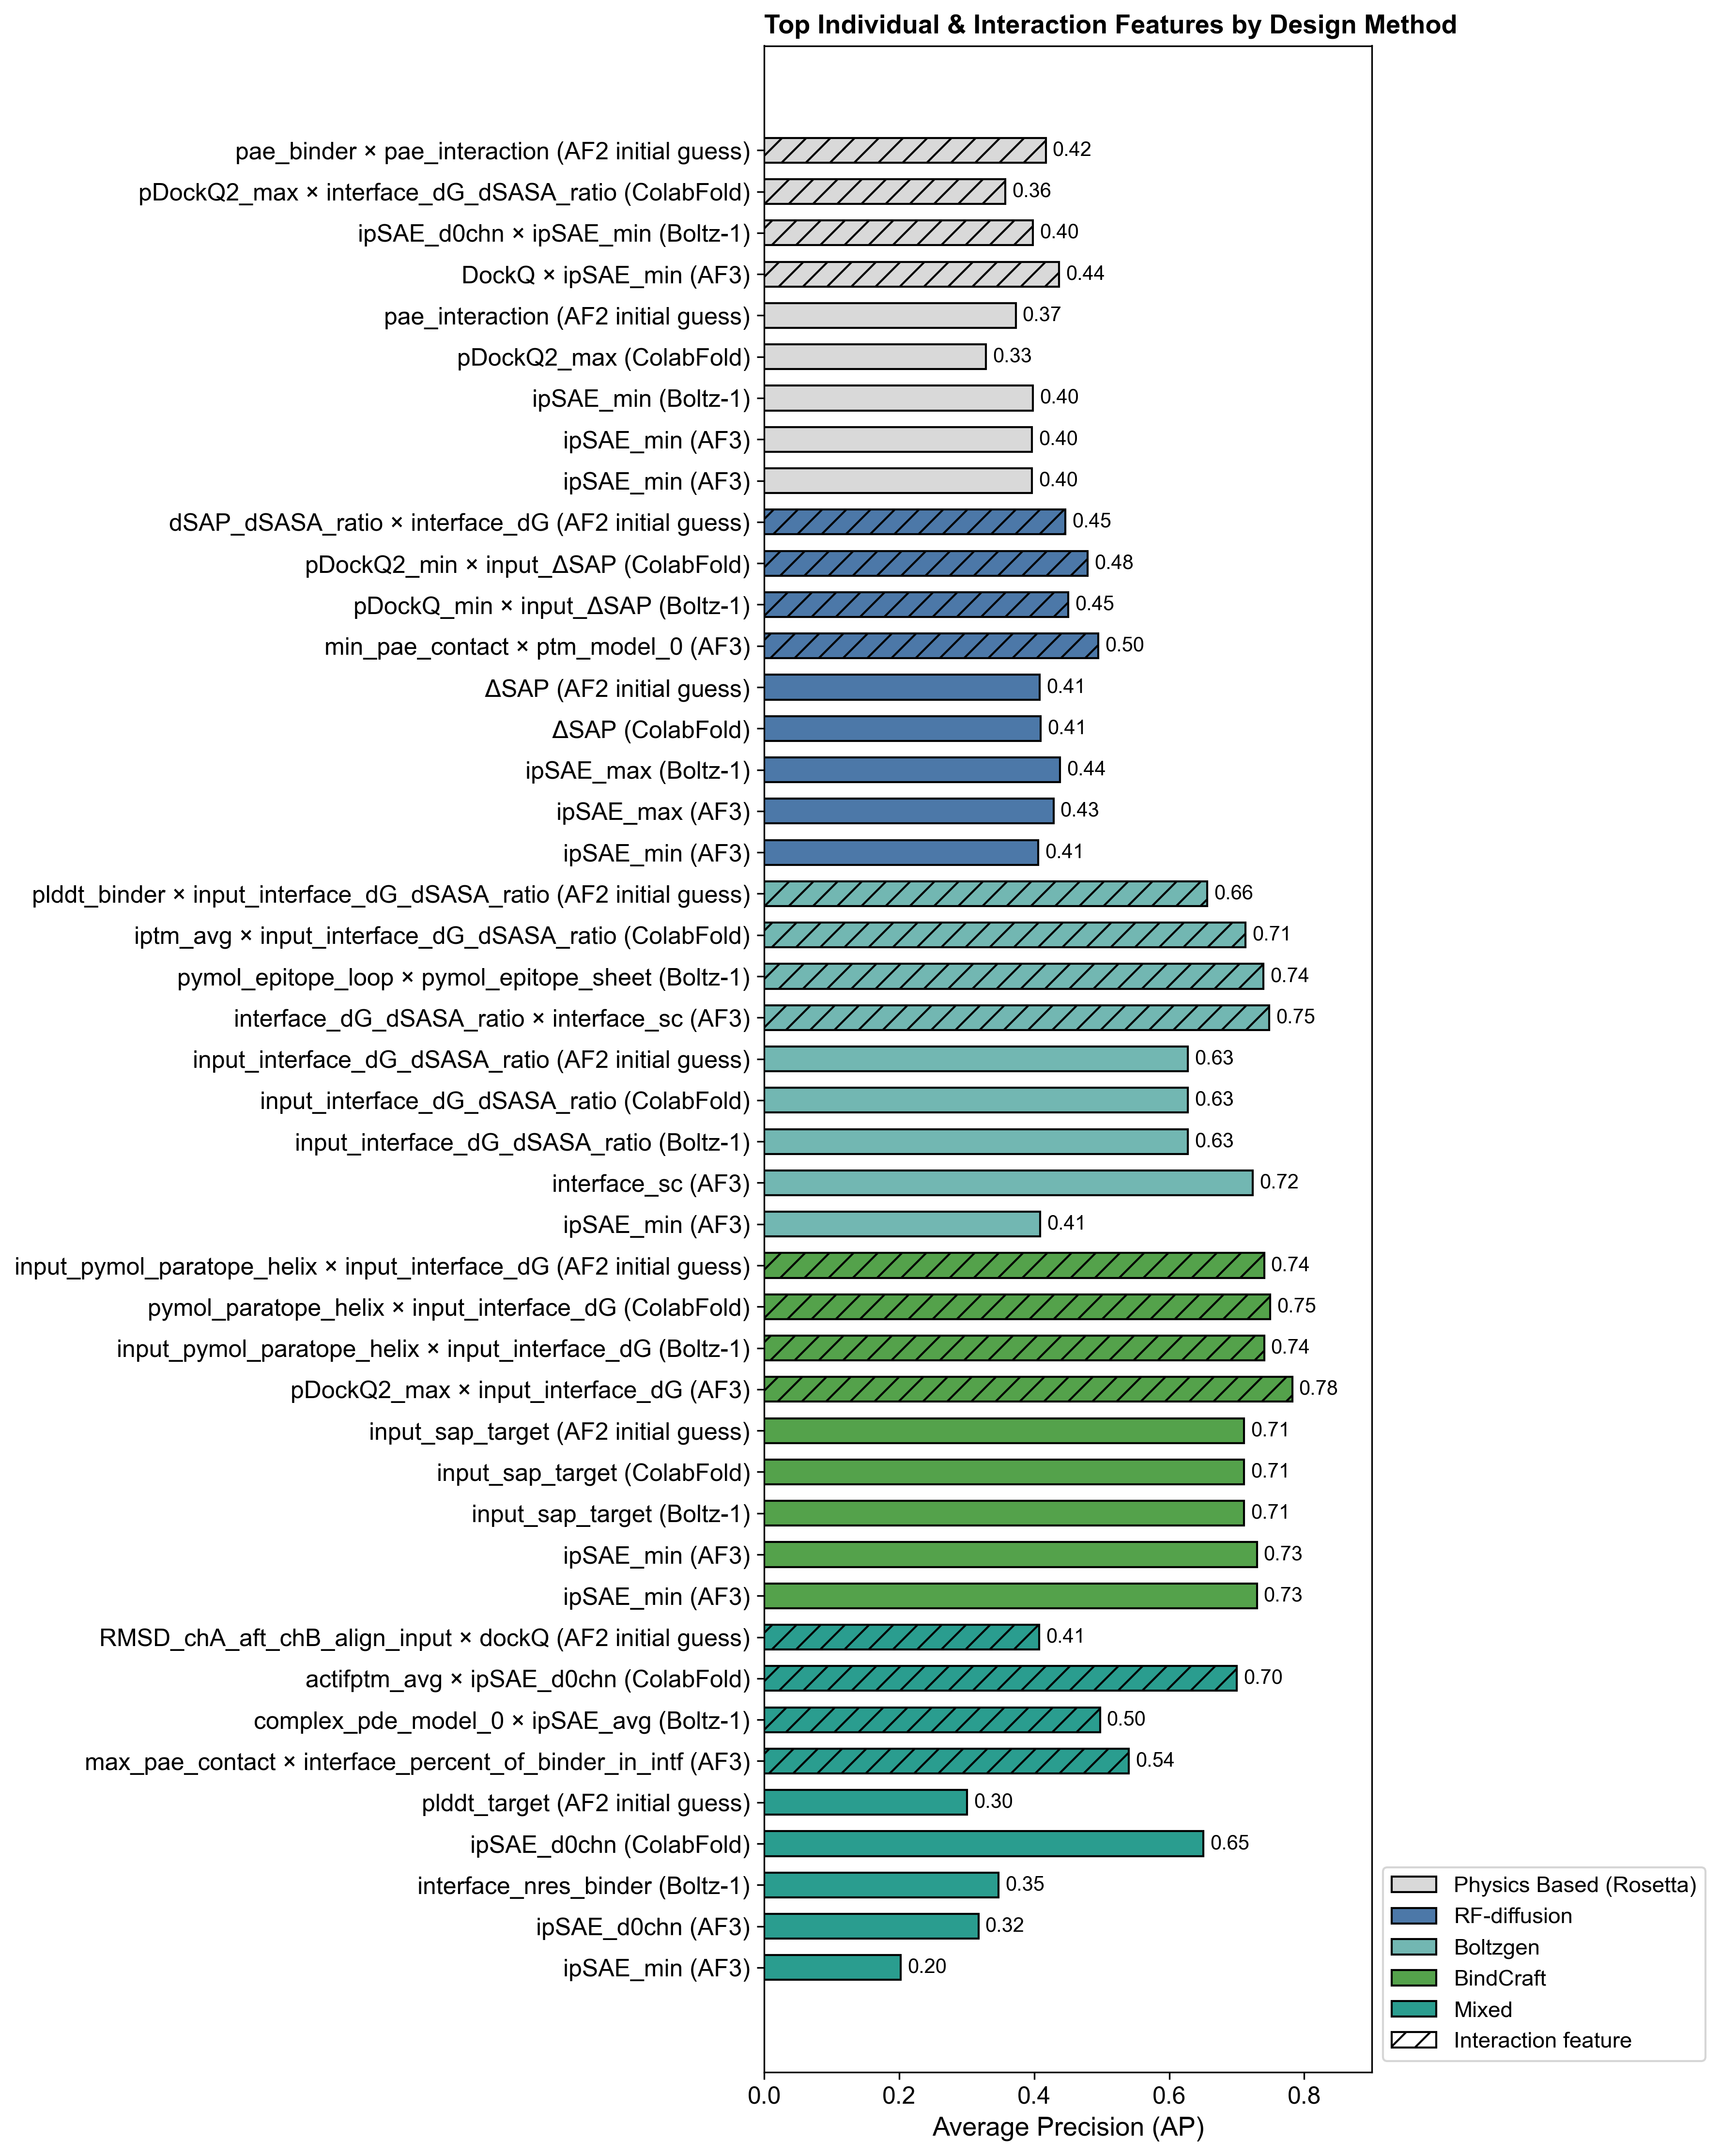

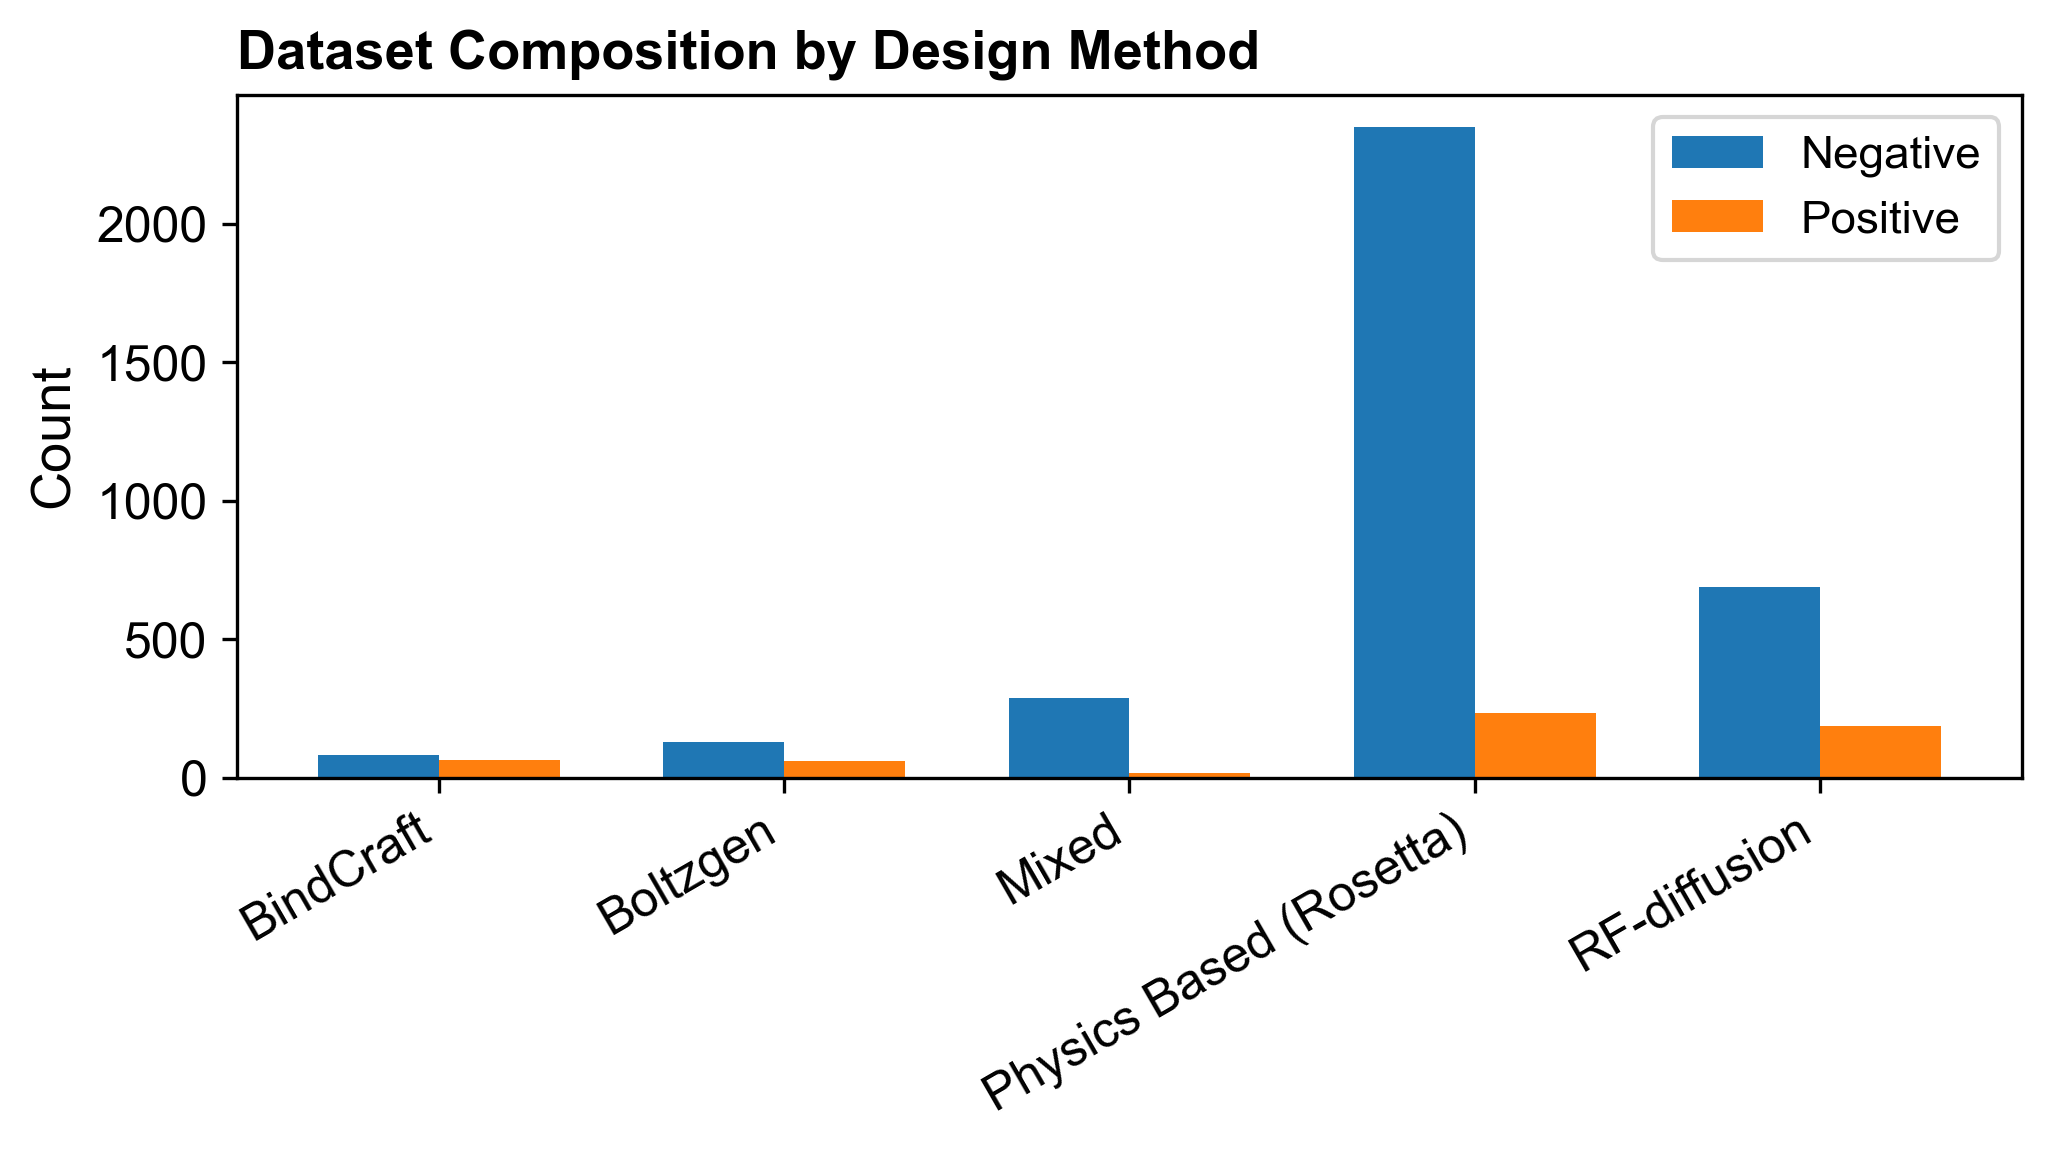

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

design_color_map = {
    'Physics Based (Rosetta)': '#d9d9d9',  # light grey
    'RF-diffusion': '#4C78A8',              # muted blue
    'Boltzgen': '#72B7B2',                  # teal
    'BindCraft': '#54A24B',                 # green
    'Mixed': '#2A9D8F',                     # blue-green
}
design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    'Mixed'][::-1]

df_plot['design_method'] = pd.Categorical(
    df_plot['design_method'],
    categories=design_order,
    ordered=True
)

df_plot = df_plot.sort_values(['design_method', 'kind', 'model_label'])

# --- Plot best metrics ---
plt.figure(dpi=300, figsize=(12,15))

y_pos = np.arange(len(df_plot))
bar_colors = [design_color_map.get(m,"#cccccc") for m in df_plot['design_method']]

for i,(kind,color) in enumerate(zip(df_plot['kind'], bar_colors)):

    hatch = '//' if kind == 'Interaction' else ''

    plt.barh(
        i,
        df_plot['ap'].iloc[i],
        color=color,
        edgecolor='black',
        height=0.6,
        hatch=hatch
    )

    plt.text(
        df_plot['ap'].iloc[i] + 0.01,
        i,
        f"{df_plot['ap'].iloc[i]:.2f}",
        va='center',
        fontsize=10
    )

plt.yticks(y_pos, df_plot['feature'])
plt.xlabel('Average Precision (AP)')
plt.xlim(0,0.9)

plt.title(
    'Top Individual & Interaction Features by Design Method',
    loc='left',
    fontweight='bold'
)

legend_elements = [
    Patch(facecolor=design_color_map[label], edgecolor='black', label=label)
    for label in design_color_map
]


interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction feature"
)

plt.legend(
    handles=legend_elements + [interaction_patch],
    loc='lower left',
    bbox_to_anchor=(1,0),
    fontsize=11
)

plt.tight_layout()
plt.show()


# --- Dataset composition plot ---
plt.figure(figsize=(7,4), dpi=300)

x = np.arange(len(summary))
width = 0.35

plt.bar(x - width/2, summary['Negative'], width, label='Negative')
plt.bar(x + width/2, summary['Positive'], width, label='Positive')

plt.xticks(x, summary.index, rotation=30, ha='right')

plt.ylabel("Count")
plt.title("Dataset Composition by Design Method", loc='left', fontweight='bold')

plt.legend()

plt.tight_layout()
plt.show()


In [7]:
summary_table = (
    df.groupby("design_method")
    .agg(
        n_targets=("target_id","nunique"),
        positives=("binder","sum"),
        negatives=("binder",lambda x: (x==0).sum())
    )
    .sort_values("n_targets", ascending=False)
)

display(summary_table)

NameError: name 'df' is not defined

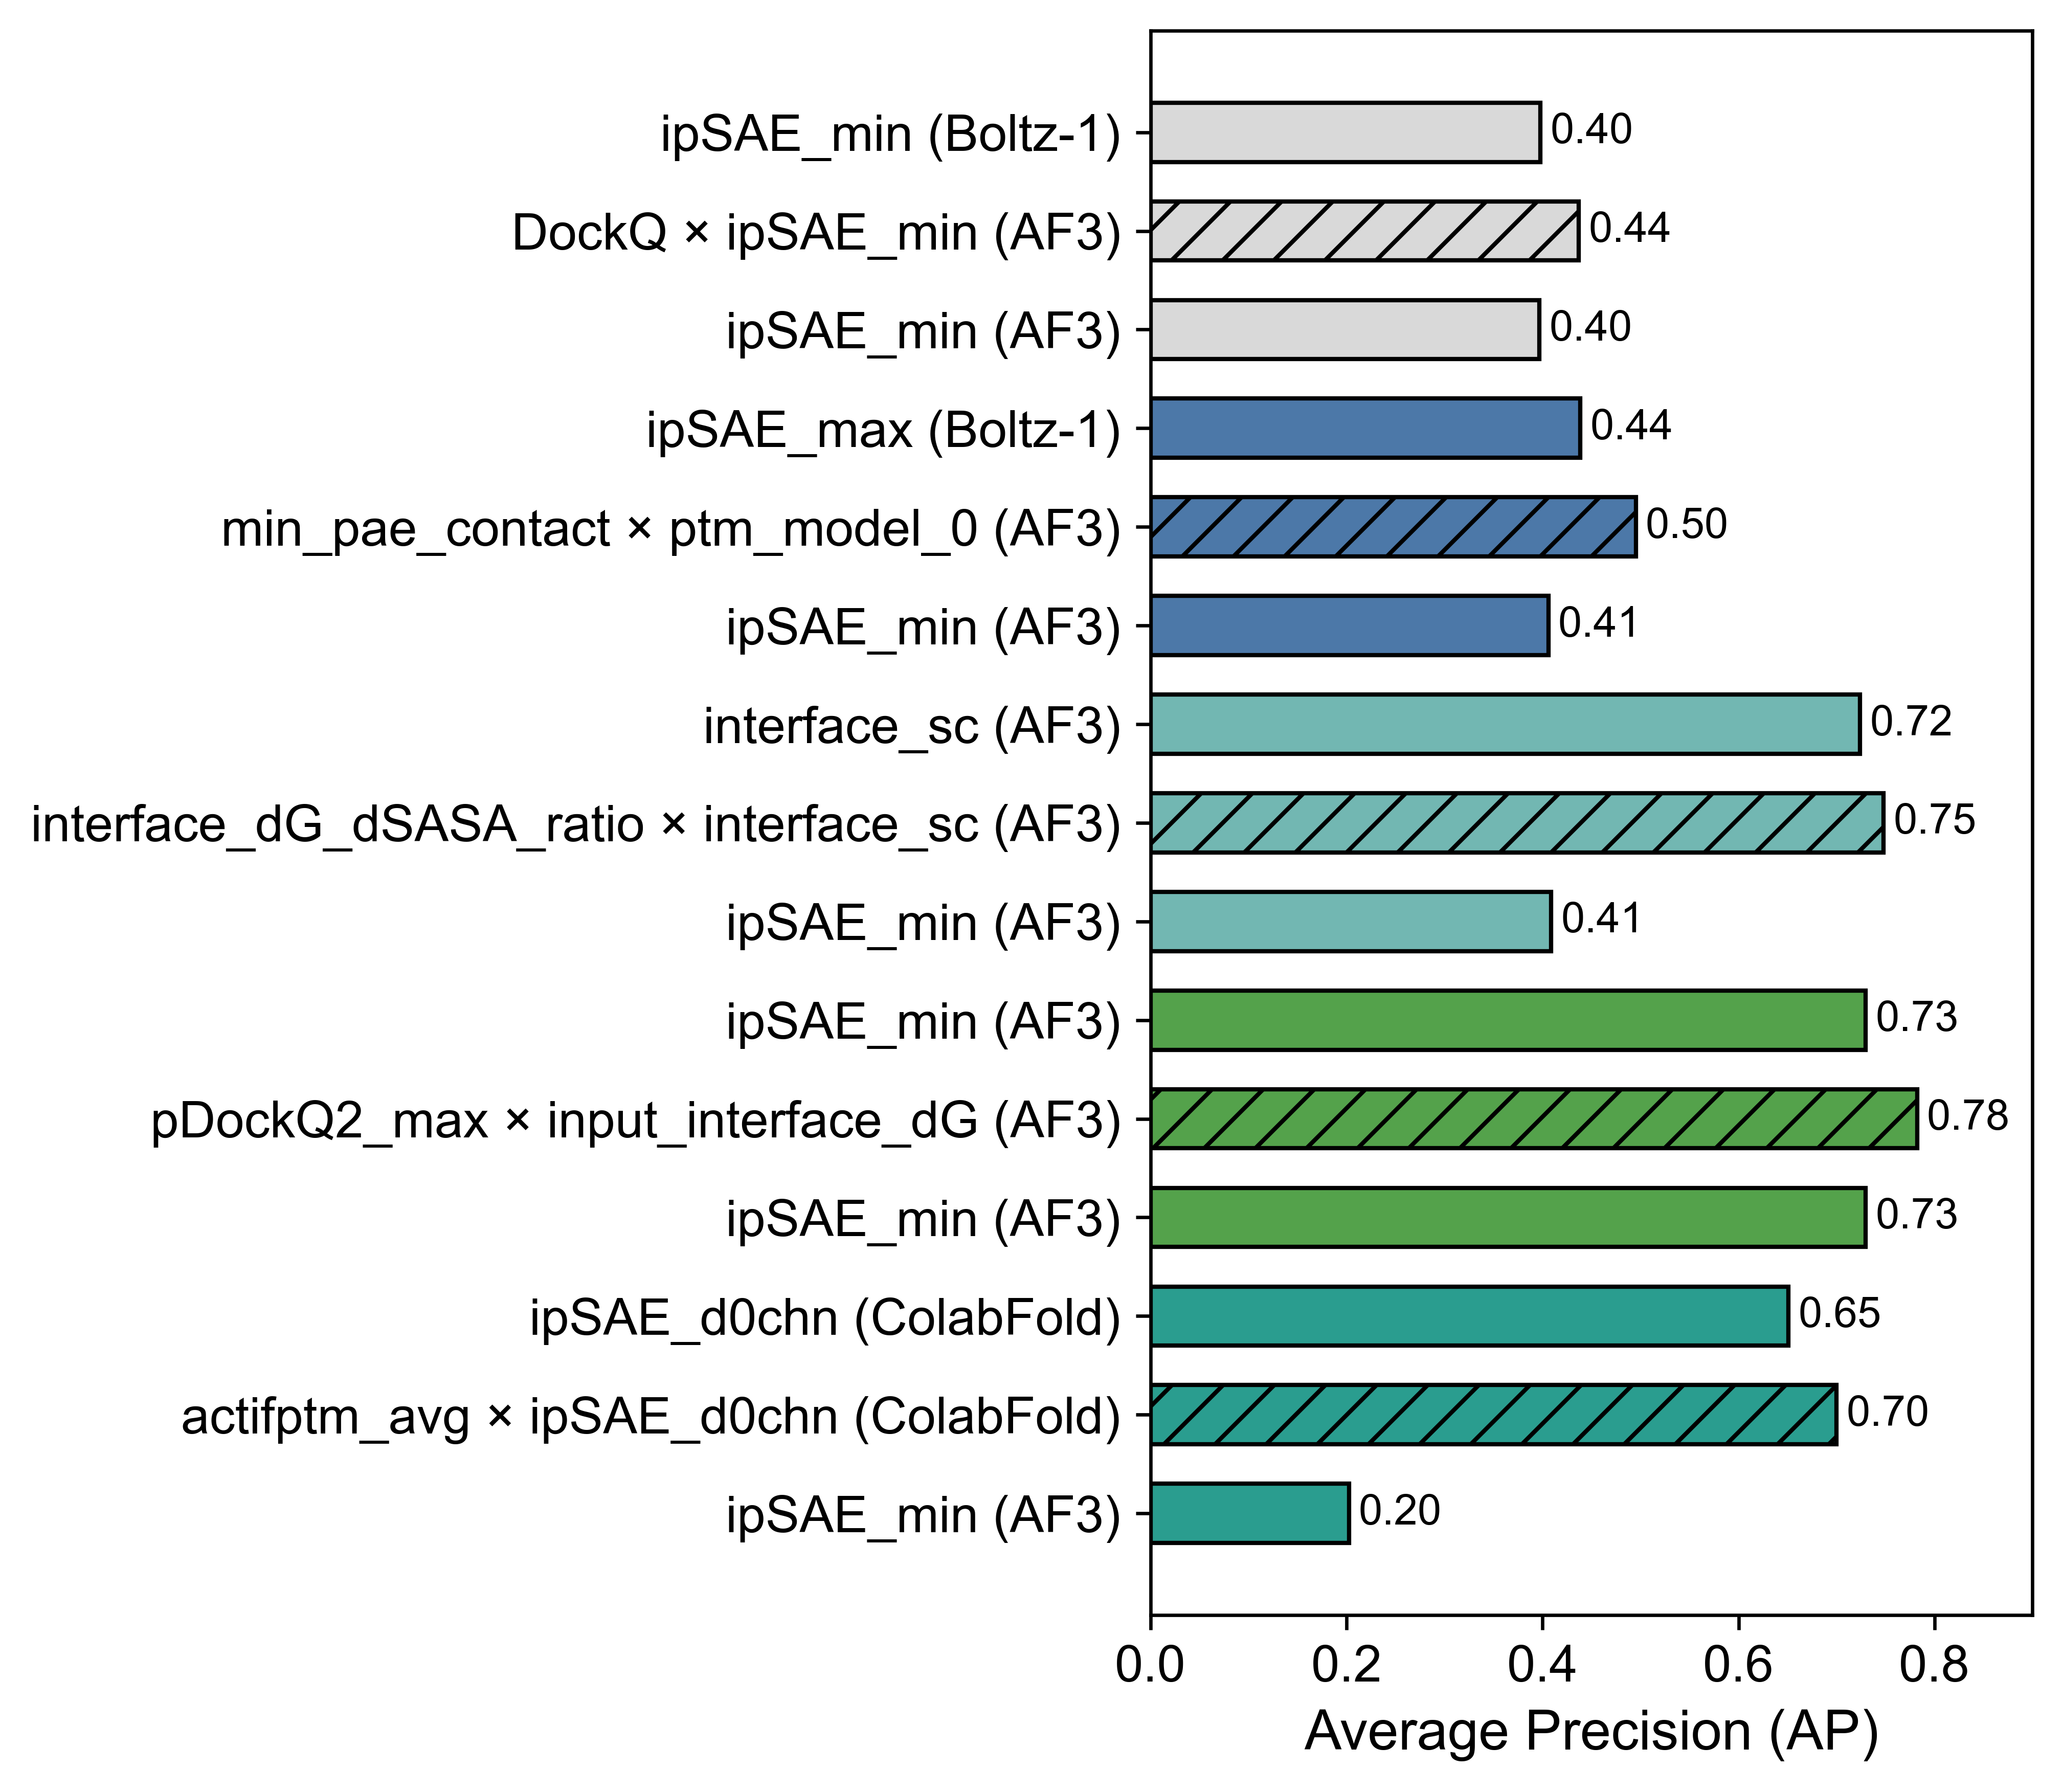

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

design_color_map = {
    'Physics Based (Rosetta)': '#d9d9d9',
    'RF-diffusion': '#4C78A8',
    'Boltzgen': '#72B7B2',
    'BindCraft': '#54A24B',
    'Mixed': '#2A9D8F',
}

design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    'Mixed'
][::-1]

# --- Get best feature per design method ---
idx = df_plot.groupby(['design_method','kind'])['ap'].idxmax()
df_best = df_plot.loc[idx].copy()

# enforce ordering
df_best['design_method'] = pd.Categorical(
    df_best['design_method'],
    categories=design_order,
    ordered=True
)

df_best = df_best.sort_values(['design_method','kind'])

# --- Plot ---
plt.figure(dpi=600, figsize=(7,6))

y_pos = np.arange(len(df_best))
bar_colors = [design_color_map[m] for m in df_best['design_method']]

for i,(row,color) in enumerate(zip(df_best.itertuples(), bar_colors)):

    hatch = '//' if row.kind == 'Interaction' else ''

    plt.barh(
        i,
        row.ap,
        color=color,
        edgecolor='black',
        height=0.6,
        hatch=hatch
    )

    plt.text(
        row.ap + 0.01,
        i,
        f"{row.ap:.2f}",
        va='center',
        fontsize=10
    )

plt.yticks(y_pos, df_best['feature'])
plt.xlabel('Average Precision (AP)')
plt.xlim(0,0.90)

# plt.title(
#     'Best Single and Interaction Features per Design Method',
#     #loc='left',
#     fontweight='bold'
# )

# --- Legend ---
legend_elements = [
    Patch(facecolor=design_color_map[label], edgecolor='black', label=label)
    for label in design_order[::-1]
]

interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction feature"
)

# plt.legend(
#     handles=legend_elements + [interaction_patch],
#     loc='lower left',
#     bbox_to_anchor=(1,0),
#     fontsize=9
# )

plt.tight_layout()
plt.savefig(f"../plots/bymethod_binder_correlation.png",dpi=600)
plt.show()

# plot with baseline

In [ ]:
df_plot=pd.read_csv("df_plotting_AP_per_medhod.csv")

df_plot = df_plot[df_plot["design_method"] != "Mixed"]
df_plot["design_method"].unique()


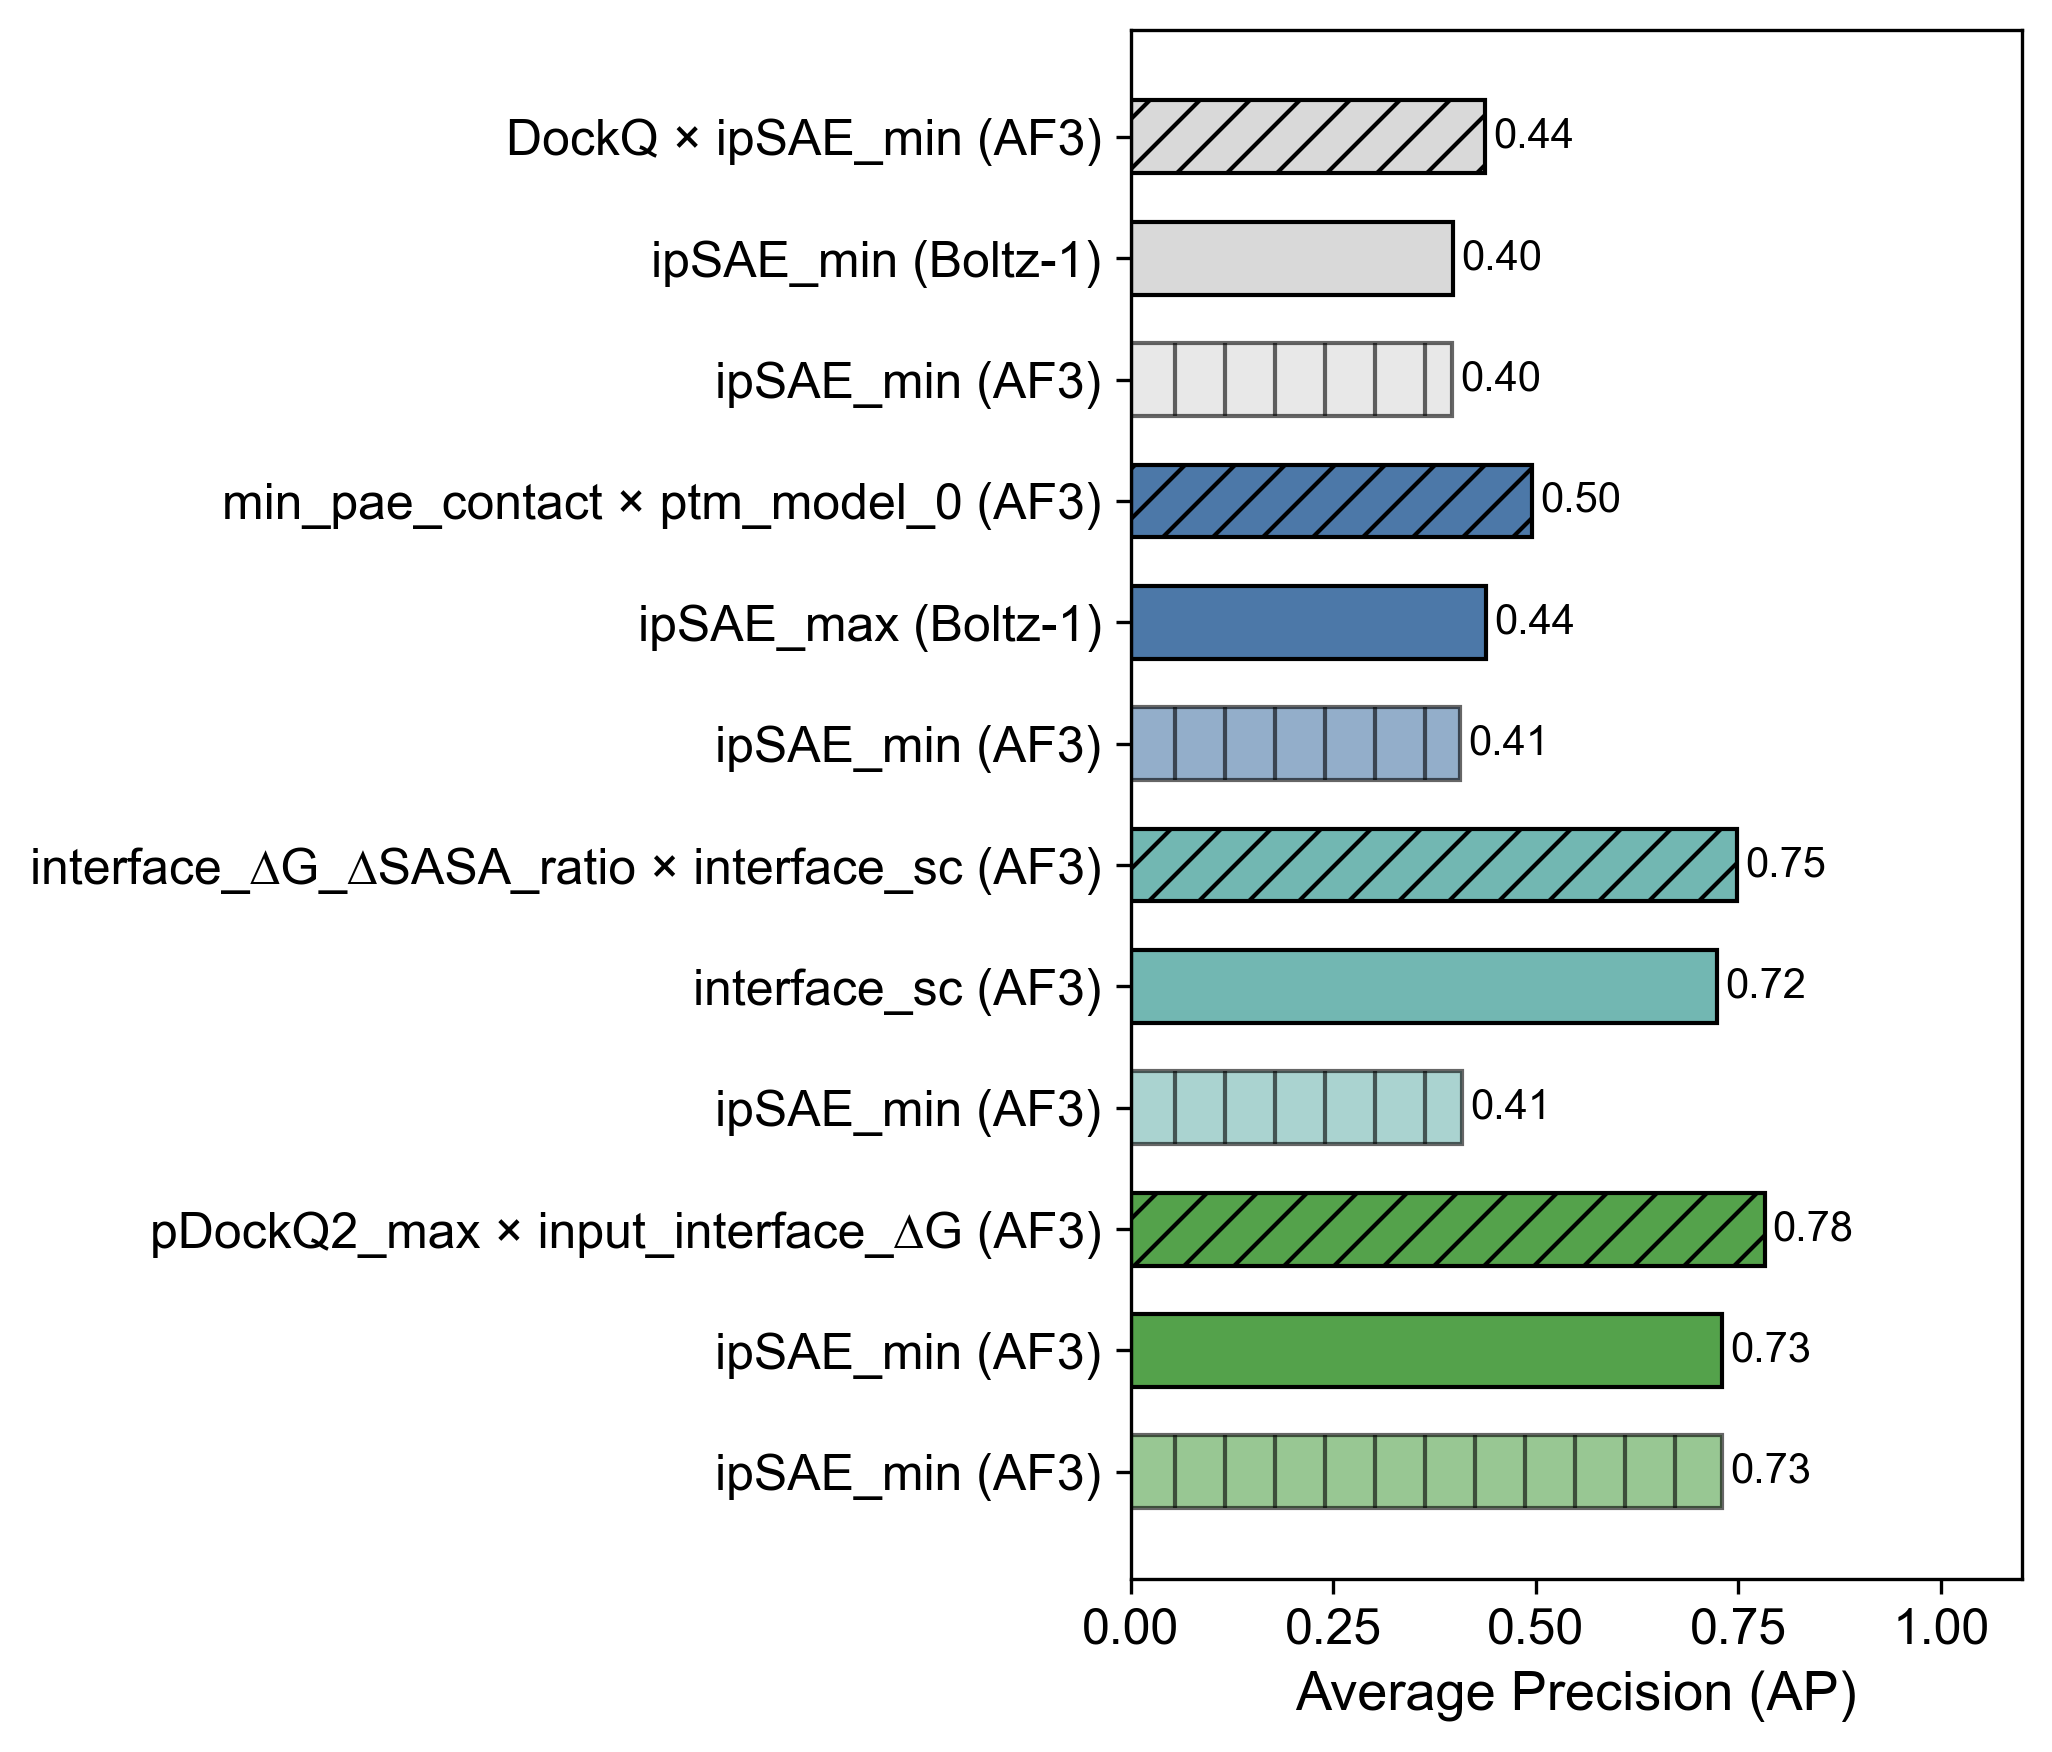

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# --- Color map ---
design_color_map = {
    'Physics Based (Rosetta)': '#d9d9d9',
    'RF-diffusion': '#4C78A8',
    'Boltzgen': '#72B7B2',
    'BindCraft': '#54A24B',
    #'Mixed': '#2A9D8F',
}

design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    #'Mixed'
][::-1]

# --- Get best feature per design method (single + interaction) ---
idx = df_plot.groupby(['design_method','kind'])['ap'].idxmax()
df_best = df_plot.loc[idx].copy()


df_best['feature'] = (
    df_best['feature']
    .str.replace('dG', '∆G', regex=False)
    .str.replace('dSASA', '∆SASA', regex=False)
)

# --- Get af3_ipSAE_min baseline per design method ---
df_baseline = df_plot[df_plot['feature'] == 'ipSAE_min (AF3)'].copy()

# ensure one baseline per design method
df_baseline = df_baseline.sort_values('ap', ascending=False) \
                         .drop_duplicates(['design_method'])

df_baseline['kind'] = 'Baseline'

# --- Combine ---
#df_best = pd.concat([df_best, df_baseline], ignore_index=True)

# --- Ordering ---
df_best['design_method'] = pd.Categorical(
    df_best['design_method'],
    categories=design_order,
    ordered=True
)

kind_order = ['Baseline', 'Single', 'Interaction']
df_best['kind'] = pd.Categorical(
    df_best['kind'],
    categories=kind_order,
    ordered=True
)

df_best = df_best.sort_values(['design_method','kind'])

# --- Plot ---
plt.figure(dpi=300, figsize=(7,6))

y_pos = np.arange(len(df_best))

for i, row in enumerate(df_best.itertuples()):

    color = design_color_map[row.design_method]

    # --- Hatch logic ---
    if row.kind == 'Interaction':
        hatch = '//'
    elif row.kind == 'Baseline':
        hatch = '|'   # different hatch for baseline
    else:
        hatch = ''     # single feature

    plt.barh(
        i,
        row.ap,
        color=color,
        edgecolor='black',
        height=0.6,
        hatch=hatch,
        alpha = 0.6 if row.kind == 'Baseline' else 1.0  # or whatever default alpha you want
    )

    plt.text(
        row.ap + 0.01,
        i,
        f"{row.ap:.2f}",
        va='center',
        fontsize=10
    )

# --- Labels ---
plt.yticks(y_pos, df_best['feature'])
plt.xlabel('Average Precision (AP)')
plt.xlim(0,1.1)

# plt.title(
#     'Best Single, Interaction, and Baseline Features per Design Method',
#     fontweight='bold'
# )

legend_elements = [
    Patch(facecolor=design_color_map[label], edgecolor='black', label=label)
    for label in design_order[::-1]
]

interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction feature"
)

baseline_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='|',
    label='Baseline (af3_ipSAE_min)'
)

# plt.legend(
#     handles=legend_elements + [interaction_patch, baseline_patch],
#     loc='lower left',
#     bbox_to_anchor=(1,0),
#     fontsize=9
# )

plt.tight_layout()
plt.savefig(f"../plots/bymethod_binder_correlation.png", dpi=600)
plt.show()

# per target

In [64]:
import pandas as pd

# Group by target_id and design_method
summary = (
    df.groupby(['target_id', 'design_method'])['binder']
      .value_counts()
      .unstack(fill_value=0)  # columns: 0 = negatives, 1 = positives
      .rename(columns={0: 'n_neg', 1: 'n_pos'})
      .reset_index()
)

# Optional: sort by target_id
summary = summary.sort_values(['target_id', 'design_method'])

print(summary)

binder      target_id            design_method  n_neg  n_pos
0                1g13                 Boltzgen     11      0
1                1jqd                 Boltzgen     13      1
2                1nb0                 Boltzgen     10      0
3                2a1x                 Boltzgen      2      5
4                2pny                 Boltzgen      5      4
5                3apu                 Boltzgen     11      0
6                3ch4                 Boltzgen     13      2
7                7aah                 Boltzgen      1     14
8                EGFR                    Mixed    286     16
9                EGFR  Physics Based (Rosetta)    120     12
10              FGFR2  Physics Based (Rosetta)   1930    193
11             IL10Ra             RF-diffusion     20      2
12              IL2Ra             RF-diffusion     60      6
13              IL7Ra  Physics Based (Rosetta)     70      7
14              IL7Ra             RF-diffusion     63     31
15           InsulinR  P

In [65]:

from tqdm import tqdm


# --- Utility functions ---
def best_ap_and_direction(vals, y):
    vals = pd.to_numeric(vals, errors='coerce').fillna(0)
    if vals.isna().all():
        return np.nan, None
    try:
        ap_high = average_precision_score(y, vals)
        ap_low  = average_precision_score(y, -vals)
    except ValueError:
        return np.nan, None
    if (not np.isnan(ap_high) and ap_high >= ap_low) or np.isnan(ap_low):
        return ap_high, False
    else:
        return ap_low, True


def valid_feature_for_model(feat, model_tag, model_tags):

    tags_in_feat = [t for t in model_tags if t in feat]

    if feat.startswith("input"):
        return (len(tags_in_feat) == 0) or (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)
    else:
        return (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)


def format_feature_name(feat, model_tags):

    if "*" in feat:

        f1, f2 = feat.split("*")

        for mt in model_tags:
            f1 = f1.replace(mt + "_", "")
            f2 = f2.replace(mt + "_", "")

        f1 = f1.replace("rosetta_", "").replace("rosetta", "")
        f2 = f2.replace("rosetta_", "").replace("rosetta", "")

        f1 = f1.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        f2 = f2.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')

        f1 = f1.replace("sap_delta", r'$\Delta$SAP')
        f2 = f2.replace("sap_delta", r'$\Delta$SAP')

        f1 = f1.replace("dockQ", 'DockQ')

        return f"{f1} × {f2}"

    else:

        for mt in model_tags:
            feat = feat.replace(mt + "_", "")

        feat = feat.replace("sap_delta", r'$\Delta$SAP')

        return feat.replace("rosetta_", "").replace("rosetta", "")



MIN_PER_CLASS = 2
DROP_SMALL_TARGETS = True

# --- Params ---
MODEL_TAGS = ['af2', 'colab', 'boltz', 'af3']

df=df_ready.copy()

df['binder'] = df['binder'].astype(int)

# --- Optional target filtering per design_method ---
if DROP_SMALL_TARGETS:

    kept_targets = []  # list of (target_id, design_method) to keep

    for (tid, design_method), group in df.groupby(['target_id', 'design_method']):
        counts = group['binder'].value_counts()
        n_pos = counts.get(1, 0)
        n_neg = counts.get(0, 0)

        if n_pos >= MIN_PER_CLASS and n_neg >= MIN_PER_CLASS:
            kept_targets.append((tid, design_method))
        else:
            print(f"Dropping target {tid} in design_method '{design_method}': "
                  f"{n_pos} positives, {n_neg} negatives (min required = {MIN_PER_CLASS})")

    # Keep only valid target/design_method combinations
    kept_df = pd.DataFrame(kept_targets, columns=['target_id', 'design_method'])
    df = df.merge(kept_df, on=['target_id', 'design_method'], how='inner')

    # Summary report
    report = df.groupby('design_method')['target_id'].nunique().reset_index()
    report = report.rename(columns={'target_id': 'n_targets_kept'})
    print("\nNumber of targets kept per design_method:")
    print(report)


feature_cols = [c for c in df.columns if c not in ['binder','design_method','target_id']]

# --- Build metric list ---
all_metrics = []

for tag in MODEL_TAGS:

    feats = [
        c for c in feature_cols
        if valid_feature_for_model(c, tag, MODEL_TAGS)
    ]

    feats = sorted(set(feats))

    # singles
    for f in feats:
        all_metrics.append((f, False, tag))

    # interactions
    for i,f1 in enumerate(feats):
        for f2 in feats[i+1:]:
            all_metrics.append((f"{f1}*{f2}", True, tag))


rows = []

# --- BASELINE: af3_ipSAE_min per target ---
baseline_feat = "af3_ipSAE_min"

if baseline_feat not in df.columns:
    print(f"[WARNING] Baseline feature '{baseline_feat}' not found in dataframe")

else:
    print("\nComputing baseline (af3_ipSAE_min) per target...")

    for (tid, design_method), group in df.groupby(['target_id', 'design_method']):

        y = group['binder'].values
        x = pd.to_numeric(group[baseline_feat], errors='coerce').fillna(0).values

        # skip constant features
        if np.unique(x).size <= 1:
            print(f"[WARNING] Skipping baseline for target {tid}, {design_method} (constant feature)")
            continue

        try:
            ap_high = average_precision_score(y, x)
            ap_low  = average_precision_score(y, -x)
        except ValueError:
            print(f"[WARNING] Failed AP for baseline on target {tid}, {design_method}")
            continue

        # --- direction per target (simpler + consistent with your pipeline)
        ap = max(ap_high, ap_low)
        lower_is_better = ap_low > ap_high

        rows.append({
            "target_id": tid,
            "design_method": design_method,
            "feature": "ipSAE_min (AF3)",  # clean name for plotting
            "model": "af3",
            "is_interaction": False,
            "ap": ap,
            "lower_is_better": lower_is_better
        })


# --- Compute AP per target ---
for feat, is_inter, tag in tqdm(all_metrics):

    ap_high_list = []
    ap_low_list = []
    per_target_data = []

    for (tid, design_method), group in df.groupby(['target_id', 'design_method']):

        y = group['binder'].values

        if is_inter:
            f1,f2 = feat.split('*')

            x = (
                pd.to_numeric(group[f1], errors='coerce').fillna(0).values *
                pd.to_numeric(group[f2], errors='coerce').fillna(0).values
            )

        else:
            x = pd.to_numeric(group[feat], errors='coerce').fillna(0).values


        if np.unique(x).size <= 1:
            continue

        ap_high = average_precision_score(y,x)
        ap_low = average_precision_score(y,-x)

        ap_high_list.append(ap_high)
        ap_low_list.append(ap_low)

        per_target_data.append((tid, design_method, ap_high, ap_low))


    if len(ap_high_list) == 0:
        continue

    # --- Decide direction globally ---
    median_high = np.median(ap_high_list)
    median_low = np.median(ap_low_list)

    lower_is_better = median_low > median_high

    for tid, design_method, ap_high, ap_low in per_target_data:

        ap = ap_low if lower_is_better else ap_high

        rows.append({
            "target_id": tid,
            "design_method": design_method,
            "feature": feat,
            "model": tag,
            "is_interaction": is_inter,
            "ap": ap,
            "lower_is_better": lower_is_better
        })

ap_per_target_df = pd.DataFrame(rows)

Dropping target 1g13 in design_method 'Boltzgen': 0 positives, 11 negatives (min required = 2)
Dropping target 1jqd in design_method 'Boltzgen': 1 positives, 13 negatives (min required = 2)
Dropping target 1nb0 in design_method 'Boltzgen': 0 positives, 10 negatives (min required = 2)
Dropping target 3apu in design_method 'Boltzgen': 0 positives, 11 negatives (min required = 2)
Dropping target 7aah in design_method 'Boltzgen': 14 positives, 1 negatives (min required = 2)
Dropping target cbago in design_method 'BindCraft': 2 positives, 0 negatives (min required = 2)
Dropping target cldn1 in design_method 'BindCraft': 6 positives, 1 negatives (min required = 2)
Dropping target her2 in design_method 'BindCraft': 1 positives, 0 negatives (min required = 2)
Dropping target sas6 in design_method 'BindCraft': 3 positives, 0 negatives (min required = 2)
Dropping target spcas9 in design_method 'BindCraft': 6 positives, 0 negatives (min required = 2)
Dropping target tnfalpha in design_method 'Bol

100%|██████████| 19993/19993 [16:30<00:00, 20.18it/s]


In [15]:
ap_per_target_df.to_csv("ap_per_target_df.csv")

NameError: name 'ap_per_target_df' is not defined

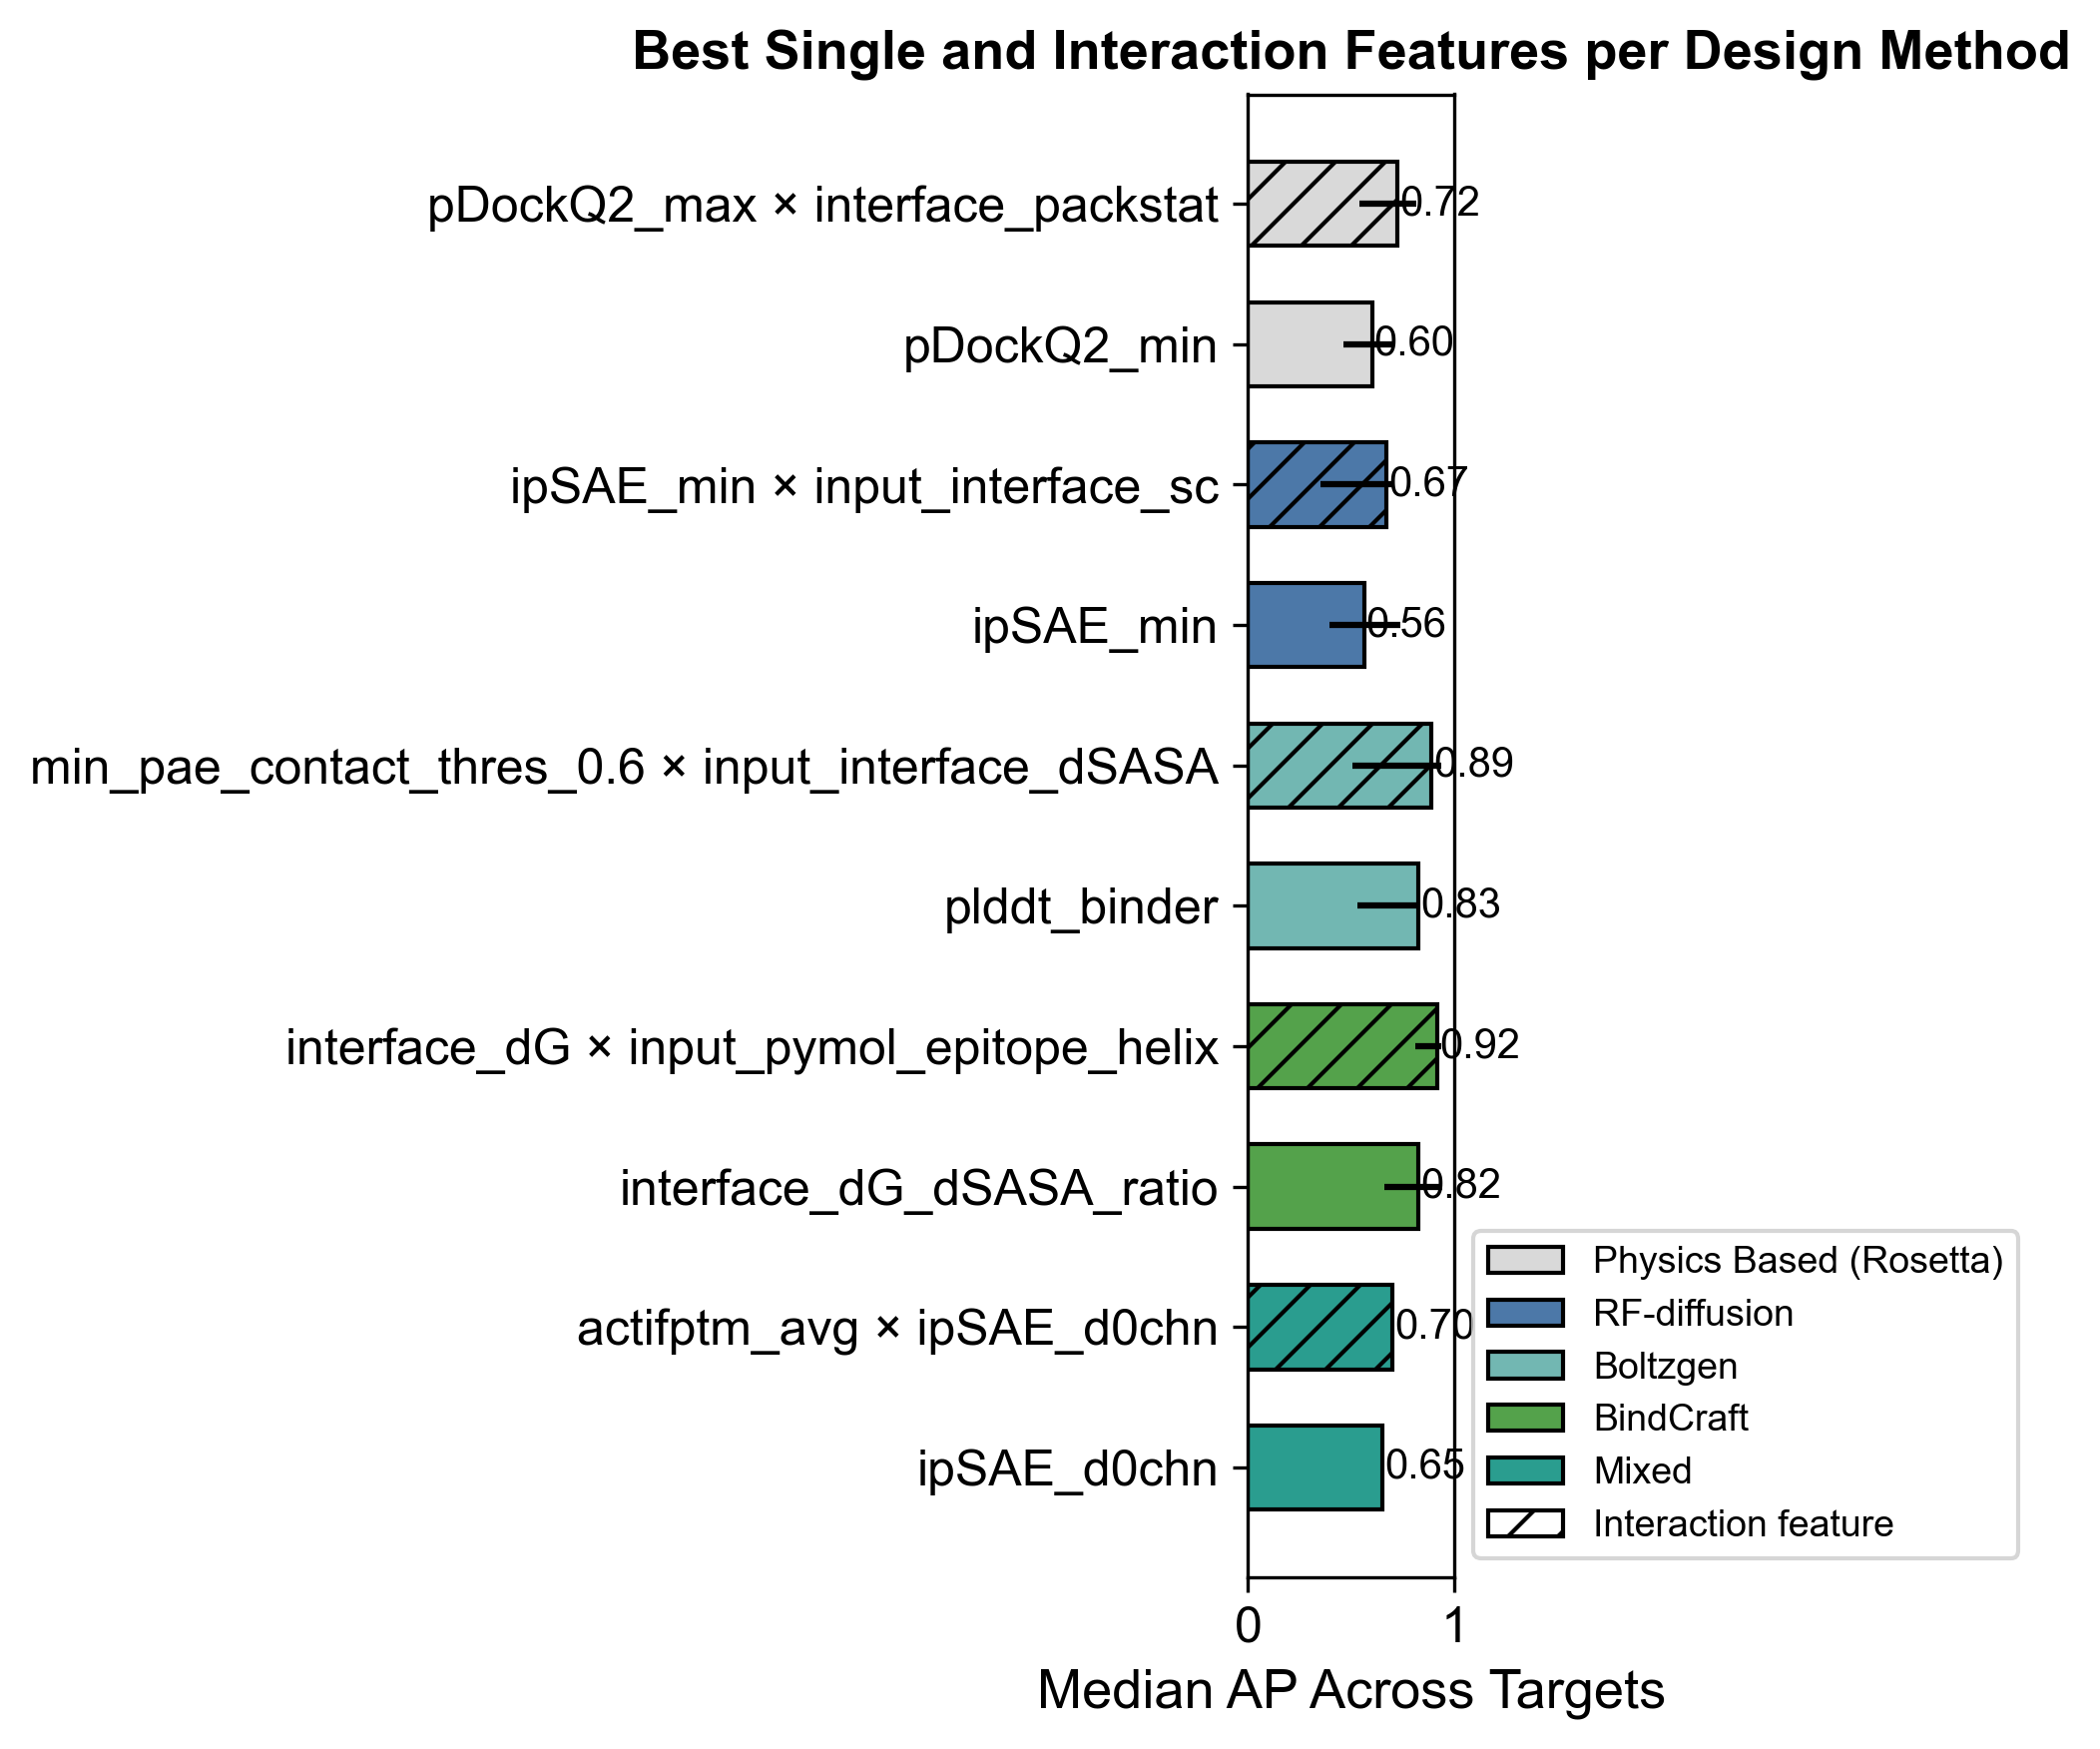

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# --- Color map ---
design_color_map = {
    'Physics Based (Rosetta)': '#d9d9d9',
    'RF-diffusion': '#4C78A8',
    'Boltzgen': '#72B7B2',
    'BindCraft': '#54A24B',
    'Mixed': '#2A9D8F',
}

design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    'Mixed'
][::-1]

# Map interaction flag to label
ap_per_target_df['kind'] = ap_per_target_df['is_interaction'].map({
    False: 'Single',
    True: 'Interaction'
})

# --- Find top feature per design method / kind based on median AP ---
rows = []

for design in design_color_map.keys():
    for kind in ['Single','Interaction']:
        subset = ap_per_target_df[
            (ap_per_target_df['design_method'] == design) &
            (ap_per_target_df['kind'] == kind)
        ]

        if subset.empty:
            continue

        medians = subset.groupby('feature')['ap'].median()
        if medians.empty:
            continue

        top_feature = medians.idxmax()
        feat_df = subset[subset['feature'] == top_feature]
        ap_values = feat_df['ap'].values

        # If only one value, no IQR
        if len(ap_values) == 1:
            q25 = q75 = np.nan
        else:
            q25 = np.percentile(ap_values, 25)
            q75 = np.percentile(ap_values, 75)

        rows.append({
            "design_method": design,
            "feature": format_feature_name(top_feature, MODEL_TAGS),
            "kind": kind,
            "median": ap_values[0] if len(ap_values)==1 else feat_df['ap'].median(),
            "q25": q25,
            "q75": q75
        })

df_best = pd.DataFrame(rows)

# --- Ordering ---
df_best['design_method'] = pd.Categorical(
    df_best['design_method'],
    categories=design_order,
    ordered=True
)
df_best['kind_order'] = df_best['kind'].map({'Single':0,'Interaction':1})
df_best = df_best.sort_values(['design_method','kind_order']).reset_index(drop=True)

# --- Plot ---
plt.figure(dpi=300, figsize=(7,6))
y_pos = np.arange(len(df_best))
bar_colors = [design_color_map[m] for m in df_best['design_method']]

for i,(row,color) in enumerate(zip(df_best.itertuples(), bar_colors)):
    hatch = '//' if row.kind == 'Interaction' else ''

    if np.isnan(row.q25) or np.isnan(row.q75):
        # only one value, no error bars
        plt.barh(
            i,
            row.median,
            color=color,
            edgecolor='black',
            height=0.6,
            hatch=hatch
        )
    else:
        plt.barh(
            i,
            row.median,
            xerr=[[row.median-row.q25],[row.q75-row.median]],
            color=color,
            edgecolor='black',
            height=0.6,
            hatch=hatch,
            capsize=0
        )

    plt.text(
        row.median + 0.01,
        i,
        f"{row.median:.2f}",
        va='center',
        fontsize=10
    )

plt.yticks(y_pos, df_best['feature'])
plt.xlabel("Median AP Across Targets")
plt.xlim(0,1)
plt.title("Best Single and Interaction Features per Design Method", fontweight="bold")

# --- Legend ---
legend_elements = [
    Patch(facecolor=design_color_map[label], edgecolor='black', label=label)
    for label in design_order[::-1]
]
interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction feature"
)
plt.legend(
    handles=legend_elements + [interaction_patch],
    loc='lower left',
    bbox_to_anchor=(1,0),
    fontsize=9
)

plt.tight_layout()
plt.savefig("../plots/bymethod_pertarget_binder_correlation",dpi=600)
plt.show()

# with baseline pllot

In [16]:
ap_per_target_df=pd.read_csv("ap_per_target_df.csv")
ap_per_target_df = ap_per_target_df[ap_per_target_df["design_method"] != "Mixed"]

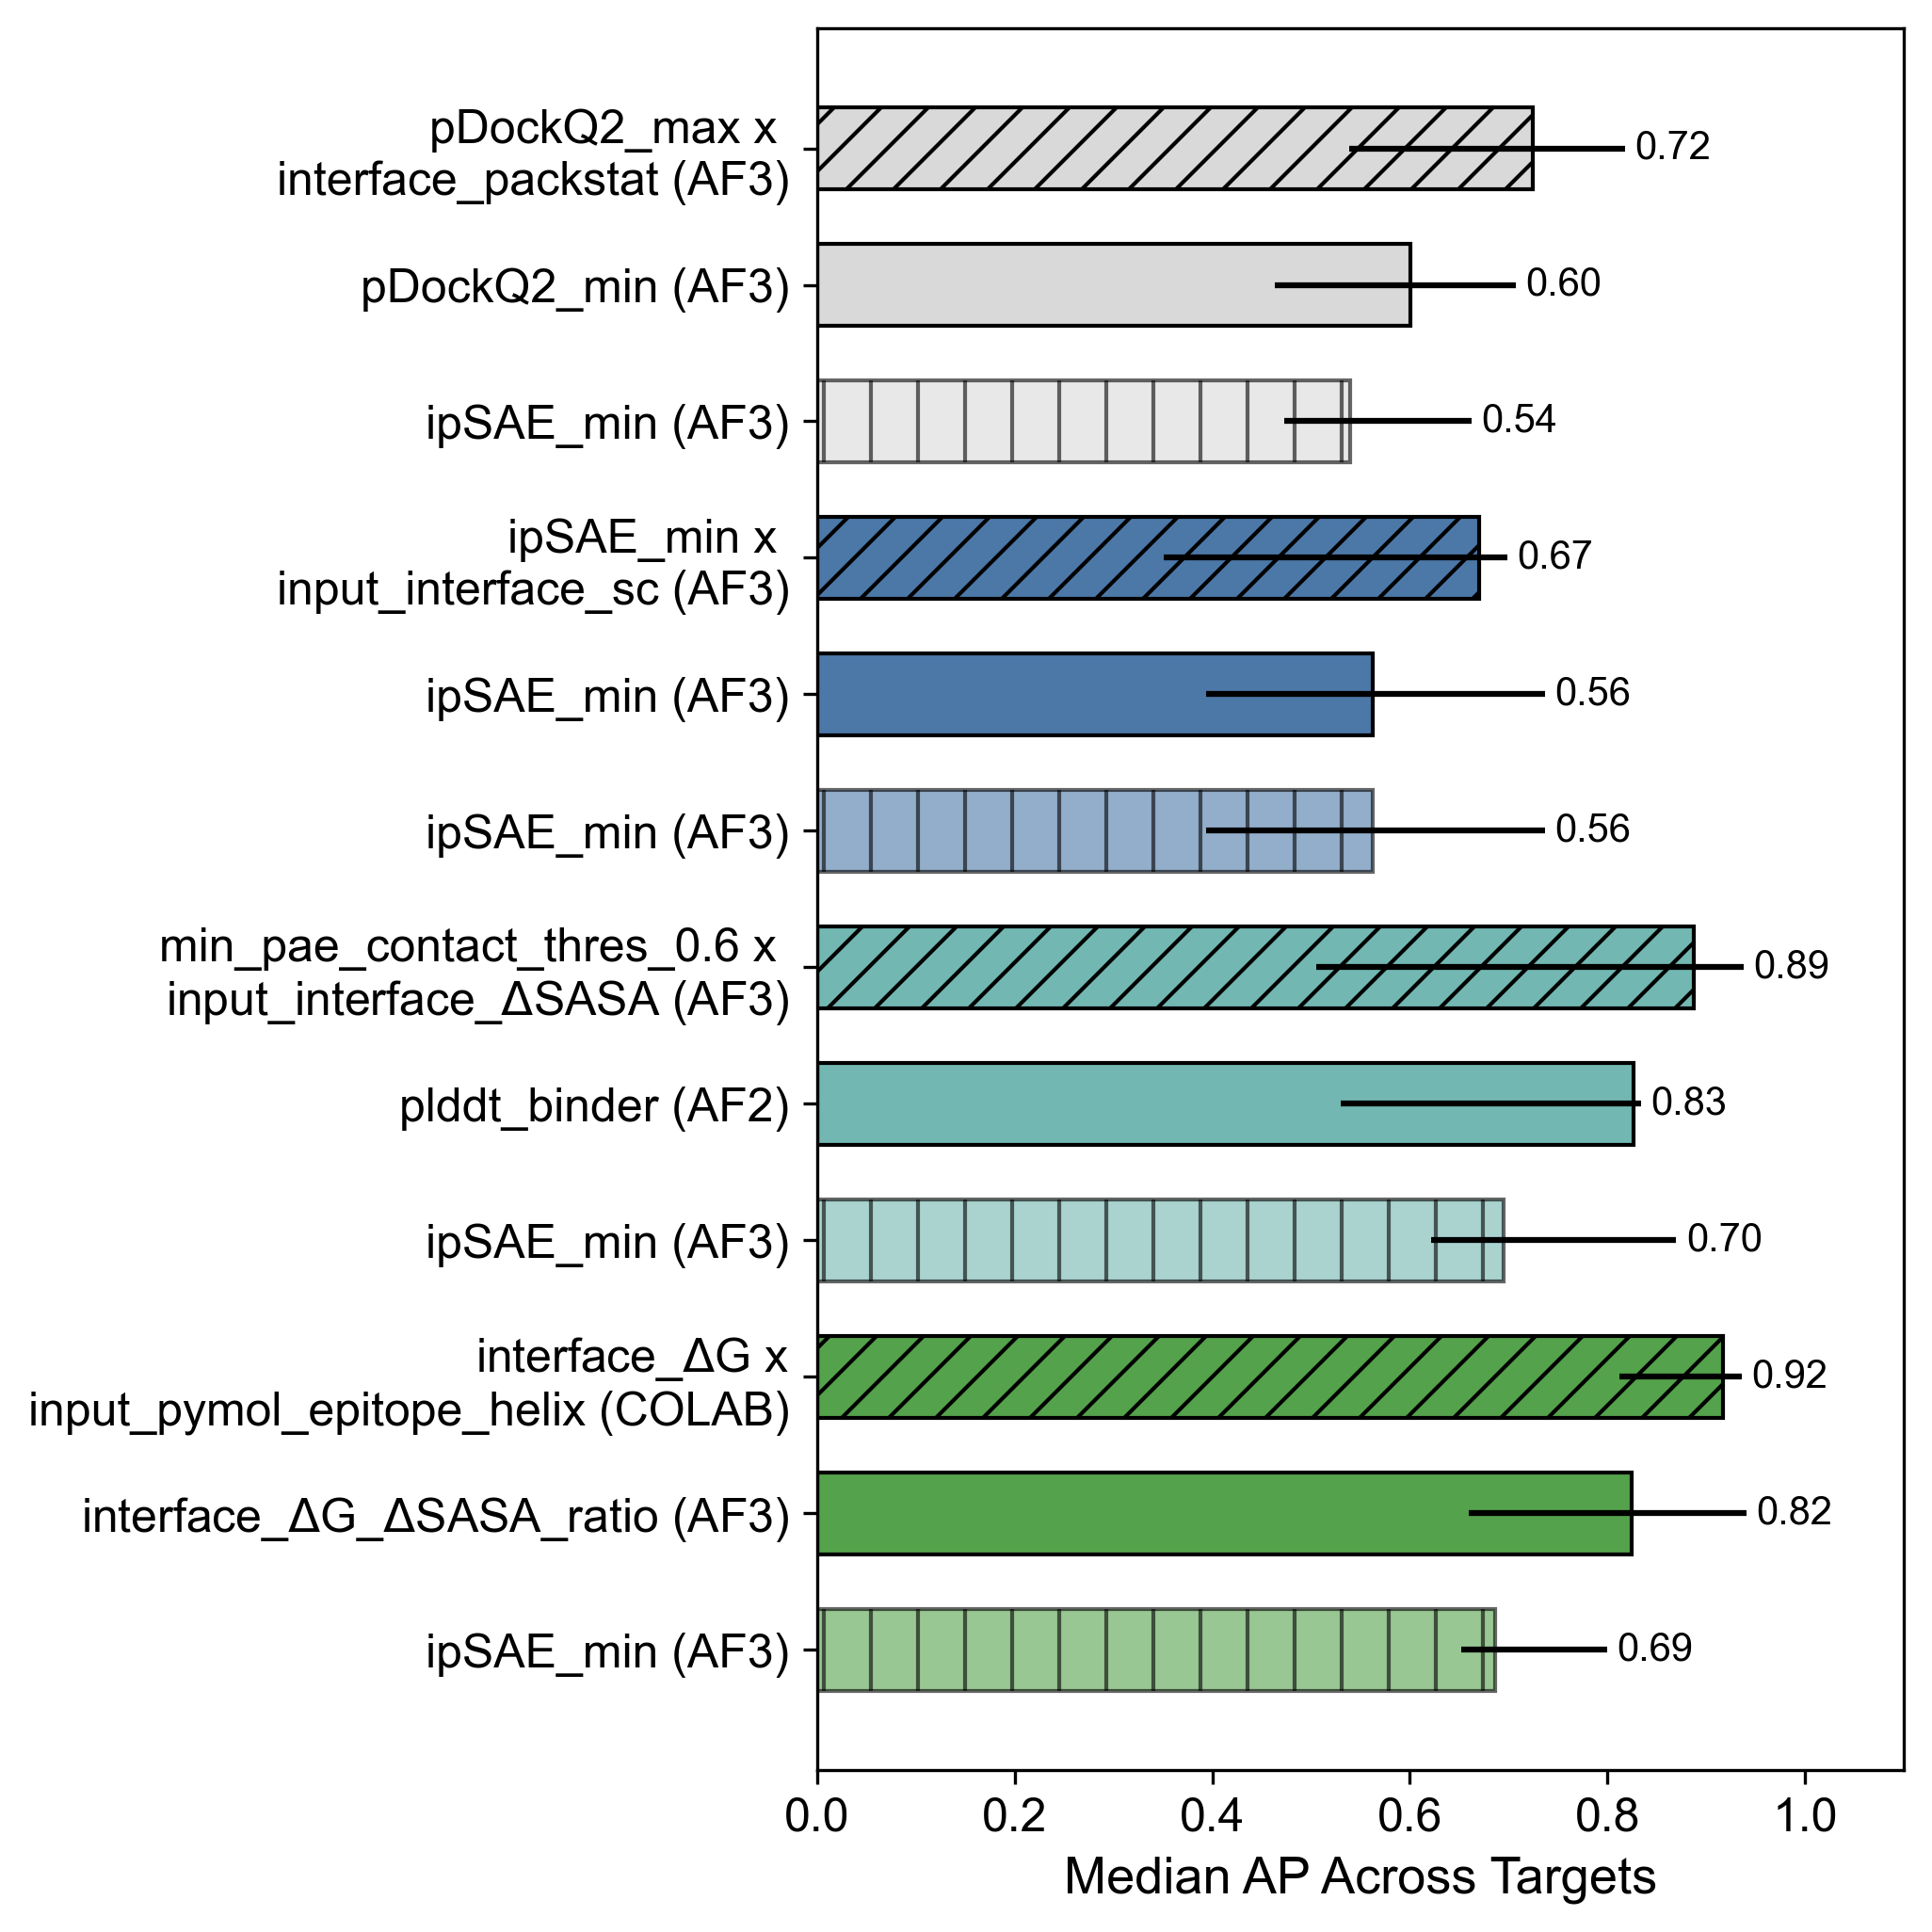

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# --- Params ---
MODEL_TAGS = ['af2', 'colab', 'boltz', 'af3']

def format_feature_name(feat, model_tags):

    if "*" in feat:

        f1, f2 = feat.split("*")

        for mt in model_tags:
            f1 = f1.replace(mt + "_", "")
            f2 = f2.replace(mt + "_", "")

        f1 = f1.replace("rosetta_", "").replace("rosetta", "")
        f2 = f2.replace("rosetta_", "").replace("rosetta", "")

        # --- NEW: dG / dSASA ---
        f1 = f1.replace("dG", r'$\Delta$G')
        f2 = f2.replace("dG", r'$\Delta$G')
        f1 = f1.replace("dSASA", r'$\Delta$SASA')
        f2 = f2.replace("dSASA", r'$\Delta$SASA')

        f1 = f1.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        f2 = f2.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')

        f1 = f1.replace("sap_delta", r'$\Delta$SAP')
        f2 = f2.replace("sap_delta", r'$\Delta$SAP')

        f1 = f1.replace("dockQ", 'DockQ')

        return f"{f1} × {f2}"

    else:

        for mt in model_tags:
            feat = feat.replace(mt + "_", "")

        feat = feat.replace("rosetta_", "").replace("rosetta", "")

        # --- NEW: dG / dSASA ---
        feat = feat.replace("dG", r'$\Delta$G')
        feat = feat.replace("dSASA", r'$\Delta$SASA')

        feat = feat.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        feat = feat.replace("sap_delta", r'$\Delta$SAP')

        return feat

# --- Color map ---
design_color_map = {
    'Physics Based (Rosetta)': '#d9d9d9',
    'RF-diffusion': '#4C78A8',
    'Boltzgen': '#72B7B2',
    'BindCraft': '#54A24B',
    #'Mixed': '#2A9D8F',
}

design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    #'Mixed'
][::-1]

# Map interaction flag to label
ap_per_target_df['kind'] = ap_per_target_df['is_interaction'].map({
    False: 'Single',
    True: 'Interaction'
})

rows = []

# --- MAIN: best single + interaction ---
for design in design_color_map.keys():
    for kind in ['Single','Interaction']:
        subset = ap_per_target_df[
            (ap_per_target_df['design_method'] == design) &
            (ap_per_target_df['kind'] == kind)
        ]

        if subset.empty:
            continue

        medians = subset.groupby('feature')['ap'].median()
        if medians.empty:
            continue

        top_feature = medians.idxmax()
        feat_df = subset[subset['feature'] == top_feature]
        ap_values = feat_df['ap'].values
        model = feat_df['model'].iloc[0]  

        if len(ap_values) == 1:
            q25 = q75 = np.nan
        else:
            q25 = np.percentile(ap_values, 25)
            q75 = np.percentile(ap_values, 75)

        rows.append({
            "design_method": design,
            "feature": f"{format_feature_name(top_feature, MODEL_TAGS)} ({model.upper()})",
            "kind": kind,
            "median": np.median(ap_values),
            "q25": q25,
            "q75": q75
        })

# --- BASELINE: af3_ipSAE_min ---
for design in design_color_map.keys():
    subset = ap_per_target_df[
        (ap_per_target_df['design_method'] == design) &
        (ap_per_target_df['feature'] == 'af3_ipSAE_min')
    ]

    if subset.empty:
        continue

    ap_values = subset['ap'].values

    if len(ap_values) == 1:
        q25 = q75 = np.nan
    else:
        q25 = np.percentile(ap_values, 25)
        q75 = np.percentile(ap_values, 75)

    rows.append({
        "design_method": design,
        "feature": "ipSAE_min (AF3)",
        "kind": "Baseline",
        "median": np.median(ap_values),
        "q25": q25,
        "q75": q75
    })

df_best = pd.DataFrame(rows)

# --- Ordering ---
df_best['design_method'] = pd.Categorical(
    df_best['design_method'],
    categories=design_order,
    ordered=True
)

kind_order_map = {'Baseline':0,'Single':1,'Interaction':2}
df_best['kind_order'] = df_best['kind'].map(kind_order_map)

df_best = df_best.sort_values(['design_method','kind_order']).reset_index(drop=True)

# --- Plot ---
plt.figure(dpi=300, figsize=(7,7))

y_pos = np.arange(len(df_best))

for i, row in enumerate(df_best.itertuples()):

    # --- Styling ---
    color = design_color_map[row.design_method]  # same for all kinds

    if row.kind == 'Baseline':
        alpha = 0.6
        hatch = '|'
    else:
        alpha = 1.0
        hatch = '//' if row.kind == 'Interaction' else ''

    # --- Plot ---
    if np.isnan(row.q25) or np.isnan(row.q75):
        plt.barh(
            i,
            row.median,
            color=color,
            edgecolor='black',
            height=0.6,
            hatch=hatch,
            alpha=alpha
        )
        x_label = row.median
    else:
        plt.barh(
            i,
            row.median,
            xerr=[[row.median-row.q25],[row.q75-row.median]],
            color=color,
            edgecolor='black',
            height=0.6,
            hatch=hatch,
            alpha=alpha,
            capsize=0
        )
        x_label = row.q75  # move label to end of IQR

    # --- Text label slightly outside the bar/IQR ---
    plt.text(
        x_label + 0.01,
        i,
        f"{row.median:.2f}",
        va='center',
        fontsize=10
    )
y_labels = df_best['feature'].str.replace(" × ", " x \n", regex=False)
plt.yticks(y_pos, y_labels)
plt.xlabel("Median AP Across Targets")
plt.xlim(0,1.1)
#plt.title("Best Single and Interaction Features per Design Method", fontweight="bold")

# --- Legend ---
legend_elements = [
    Patch(facecolor=design_color_map[label], edgecolor='black', label=label)
    for label in design_order[::-1]
]

interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction feature"
)

baseline_patch = Patch(
    facecolor='white',   # you can also use facecolor='none' for transparent, hatch will show
    edgecolor='black',
    hatch='|',
    alpha=0.6,
    label='af3_ipSAE_min (baseline)'
)

# plt.legend(
#     handles=legend_elements + [interaction_patch, baseline_patch],
#     loc='lower left',
#     bbox_to_anchor=(1,0),
#     fontsize=9
# )

plt.tight_layout()
plt.savefig("../plots/bymethod_pertarget_binder_correlation", dpi=600)
plt.show()

In [ ]:

import pandas as pd

# read csv
df_1 = pd.read_csv("/zhome/projects/project.maxove.anryg/classifying_binders/data/prepared_training_dataset_publish.csv")

# import pandas as pd


# filter for the two Adaptyv rounds
rounds_of_interest = [
    "Adaptyv binder comp round 1",
    "Adaptyv binder comp round 2"
]
df_filtered = df_1[df_1["source"].isin(rounds_of_interest)]

# summarize counts per binder
binder_counts = df_filtered["binder"].value_counts().reset_index()
binder_counts.columns = ["binder", "count"]

print(binder_counts)

# overview plot

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Count binders / non-binders per design method
counts = (
    df.groupby(["design_method", "binder"])
      .size()
      .unstack(fill_value=0)
)

# Rename columns if binder = 0/1
counts = counts.rename(columns={0: "non_binder", 1: "binder"})

# Ensure all methods appear
counts = counts.reindex(design_color_map.keys(), fill_value=0)

fig, ax = plt.subplots(figsize=(8,5))

y_pos = range(len(counts))

for i, method in enumerate(counts.index):

    non_binder = counts.loc[method, "non_binder"]
    binder = counts.loc[method, "binder"]
    color = design_color_map[method]

    # Non-binders
    ax.barh(
        i,
        non_binder,
        color=color,
        edgecolor="black"
    )

    # Binders (hatched)
    ax.barh(
        i,
        binder,
        left=non_binder,
        color=color,
        hatch="..",
        edgecolor="black"
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(counts.index)

ax.set_xlabel("Number of designs")
ax.set_title("Binders vs Non-binders by Design Method")

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

/tmp/ipykernel_924911/53525394.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in counts.groupby("design_method"):


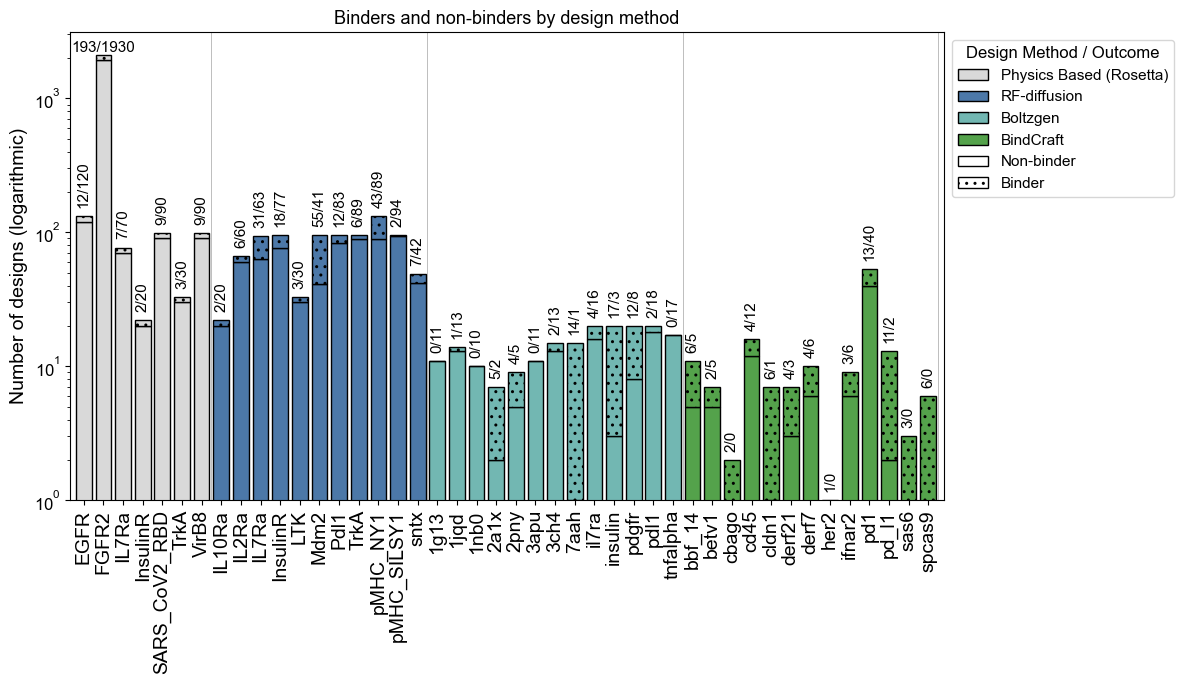

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

design_order = [
    'Physics Based (Rosetta)',
    'RF-diffusion',
    'Boltzgen',
    'BindCraft',
    #'Mixed'
]

df_ready = df_ready[df_ready["design_method"] != "Mixed"]

# Count binders / non-binders
counts = (
    df_ready.groupby(["design_method", "target_id", "binder"])
      .size()
      .unstack(fill_value=0)
)

counts = counts.rename(columns={0: "non_binder", 1: "binder"}).reset_index()

# enforce design method order
counts["design_method"] = pd.Categorical(
    counts["design_method"],
    categories=design_order,
    ordered=True
)

counts = counts.sort_values(["design_method", "target_id"]).reset_index(drop=True)

x_positions = np.arange(len(counts))

fig, ax = plt.subplots(figsize=(12,7))

for i, row in counts.iterrows():

    method = row["design_method"]
    color = design_color_map[method]

    nonbinder = row["non_binder"]
    binder = row["binder"]
    total = nonbinder + binder

    # Non-binder
    ax.bar(
        x_positions[i],
        nonbinder,
        color=color,
        edgecolor="black"
    )

    # Binder (hatched)
    ax.bar(
        x_positions[i],
        binder,
        bottom=nonbinder,
        color=color,
        hatch="..",
        edgecolor="black"
    )
    if total > 1000:
            # --- label counts above bar ---
        ax.text(
            x_positions[i],
            total * 1.0,                 # offset for log axis
            f"{binder}/{nonbinder}",      # pos/neg
            ha="center",
            va="bottom",
            #rotation=,
            fontsize= 11
        )
    else:
            # --- label counts above bar ---
        ax.text(
            x_positions[i],
            total * 1.15,                 # offset for log axis
            f"{binder}/{nonbinder}",      # pos/neg
            ha="center",
            va="bottom",
            rotation=90,
            fontsize= 11
        )

# X axis
ax.set_xticks(x_positions)
ax.set_xticklabels(counts["target_id"], rotation=90,fontsize=14)

# Log axis
ax.set_yscale("log")

ax.set_ylabel("Number of designs (logarithmic)",fontsize=14)
ax.set_title("Binders and non-binders by design method")

# --- group centers for method labels ---
group_centers = {}
for method, g in counts.groupby("design_method", observed=True):
    start = g.index.min()
    end = g.index.max()
    group_centers[method] = (start + end) / 2

# for method, center in group_centers.items():
#     ax.text(
#         center,
#         ax.get_ylim()[1] * 0.7,
#         method,
#         ha="center",
#         va="bottom",
#         fontsize=11,
#         #fontweight="bold"
#     )

# --- legend ---
method_patches = [
    Patch(facecolor=design_color_map[m], edgecolor="black", label=m)
    for m in design_order if m in counts["design_method"].values
]

binder_patches = [
    Patch(facecolor="white", edgecolor="black", label="Non-binder"),
    Patch(facecolor="white", edgecolor="black", hatch="..", label="Binder")
]

ax.legend(
    handles=method_patches + binder_patches,
    title="Design Method / Outcome",
    bbox_to_anchor=(1.0, 1),
    loc="upper left",
    fontsize=11
)
for _, g in counts.groupby("design_method"):
    ax.axvline(g.index.max() + 0.5, color="grey", linewidth=0.6,alpha=0.6)

ax.set_xlim(-0.7, len(x_positions) - 0.2)
plt.tight_layout()
plt.savefig("../plots/dataset_overview.png",dpi=600)
plt.show()

In [ ]:
summary_table = counts[[
    "design_method",
    "target_id",
    "binder",
    "non_binder"
]].rename(columns={
    "binder": "positives",
    "non_binder": "negatives"
})

print(summary_table)